In [1]:
## 2026.07.25 Copy from Xenium_lung/Lung_train_validate_cv_UNIlabel_single.ipynb → CODEX HCC
## Paths follow demo_GT_feature_extraction_Single.sh:
##   data/CODEX/HCC/Michael_data_transfer/s4769/HE/{MATCHED_HE}/project_all_UNI/
## Example: therapy_data = 'awy-98938_aligned_0d535a74'
##   ↔ CODEX_ACQUISITION_ID = FinalLiv-27_c001_v001_r001_reg001
## Feature extraction:
##   bash code/CODEX_hcc/demo_GT_feature_extraction_Single.sh gt
##   bash code/CODEX_hcc/demo_GT_feature_extraction_Single.sh stardist
##
## 2026.08.12 Preprocess CSV inputs (run before this notebook; Xenium-style):
##   python code/CODEX_hcc/match_codex_cells_with_pixel.py --he-key {MATCHED_HE}
##   writes:
##     HE/{MATCHED_HE}/{MATCHED_HE}_cells_with_pixel.csv
##     HE/{MATCHED_HE}/{MATCHED_HE}_cells_matched_by_stardist.csv
##   StarDist CSV source is only data/CODEX/HCC/StarDist_Segment/{MATCHED_HE}/
##   (no rebuild from UNI .pth filenames).
## This notebook generates matched h5ad once:
##   {MATCHED_HE}_matched_features.h5ad
##   {MATCHED_HE}_matched_features_stardist.h5ad

## CLI twin (36 ALIGNED regions + spatial k=8/mean): code/CODEX_hcc/HCC_train_validate_cv_UNIlabel.py
##   python -u code/CODEX_hcc/HCC_train_validate_cv_UNIlabel.py --sample awy-98938_aligned_0d535a74
##   python -u code/CODEX_hcc/HCC_train_validate_cv_UNIlabel.py --mode cross-dataset
##
## 2026.08.12 Spatial context (same as lung CLI defaults):
##   use_spatial_context=True, build_spatial_neighbor_index, spatial_k=8, spatial_mode='mean'

## 2026.08.10 update the notebook using output files from 2_match_codex_cells_with_pixel.py 



In [2]:
import os
# Pin to ONE physical GPU before any torch import (restart kernel after changing).
# Physical GPU index on this machine (default 2). Override without editing notebook:
#   export NCRT_CUDA_DEVICE=0
# Or set CUDA_VISIBLE_DEVICES yourself before starting Jupyter (then this block is skipped).
if "CUDA_VISIBLE_DEVICES" not in os.environ:
    os.environ["CUDA_VISIBLE_DEVICES"] = os.environ.get("NCRT_CUDA_DEVICE", "0")
NCRT_PHYSICAL_GPU = os.environ["CUDA_VISIBLE_DEVICES"].split(",")[0].strip()

# Before other imports: PyTorch/torch.distributed may use /tmp; set NCRT_TMPDIR if quota is tight.
_nrtc_tmp = os.environ.get("NCRT_TMPDIR", os.path.join(os.path.expanduser("~"), "ssd2", "tmp"))
try:
    os.makedirs(_nrtc_tmp, exist_ok=True)
    os.environ["TMPDIR"] = _nrtc_tmp
    os.environ["TEMP"] = _nrtc_tmp
    os.environ["TMP"] = _nrtc_tmp
    import tempfile as _tf_nb
    _tf_nb.tempdir = _nrtc_tmp
except OSError:
    pass

import sys
import importlib
import pandas as pd
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

_xenium_lung_dir = f'{path}Hist2Pheno/code/Xenium_lung/'
if _xenium_lung_dir not in sys.path:
    sys.path.insert(0, _xenium_lung_dir)

_codex_hcc_dir = f'{path}Hist2Pheno/code/CODEX_hcc/'
if _codex_hcc_dir not in sys.path:
    sys.path.insert(0, _codex_hcc_dir)

## Import (or reload) base module
# Do NOT `import model` — that binds the name ``model`` to the *module* and will shadow
# your trained ``torch.nn.Module`` after ``globals().update(LP)`` when this cell is re-run.
import base
import plot
import model as model_pkg
## Impost：Force reload base.py
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

import xenium_uni_nb_helpers as uni_nb
importlib.reload(uni_nb)
from xenium_uni_nb_helpers import (
    ensure_lp_extra_insample_preds,
    stardist_head_preds,
    plot_he_confusion_matrices,
    plot_he_spatial_extra_tiers,
    plot_he_f1_extra_tiers,
    build_insample_tier_metrics,
    build_stardist_matched_tier_metrics,
    save_stardist_external_validation_metrics,
    plot_stardist_roc_from_auroc_csv,
    _auroc_csv_path_from_metrics,
    plot_stardist_spatial_extra,
    plot_stardist_acc_extra,
    plot_stardist_confusion_extra,
    plot_stardist_f1_extra,
    plot_stardist_roc_extra,
)

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords,load_hist_embeddings,
    match_hist2cell_matrix,
    match_hist2cell_h5ad,
    load_matched_h5ad,
    prepare_data_from_matched_h5ad,
    adata_X_to_dense,
    load_matched_features_bundle,
    encode_labels_with_class_names,
    matched_features_npz_to_h5ad,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    collect_hce_tier_metrics_extras,
    split_train_test,
    prepare_data_leave_one_group_out,
    spatial_tile_groups_for_logo,
    build_spatial_neighbor_index,
    loader_train_test,
    first_pth_tensor
    
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_level1_spatial_distribution,
    plot_tier_spatial_distribution,
    plot_per_class_f1,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions,
    mlp_collect_softmax_probs,
    mlp_collect_five_head_softmax_probs,
    plot_multiclass_roc_curves,
    plot_level1_roc_from_level2_scores,
    plot_level1_f1_from_level2_predictions,
    plot_level1_accuracy_from_level1_head,
    plot_level1_f1_from_level1_head,
    plot_level1_roc_from_level1_head
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    get_select4_best_checkpoint_path,
    sync_best_mlp_from_logo_fold,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split,
    train_hce_leave_one_group_out_cv,
    run_logo_cv_and_load_best_model,
    report_logo_cv_means_and_insample_eval,
    run_logo_cv_with_insample_report,
    run_stratified_kfold_cv_with_insample_report,
    predict_all_label_heads,
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')} (physical GPU {NCRT_PHYSICAL_GPU})")


Successfully reloaded functions from base.py
openslide: False, tifffile: True
CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


In [3]:
## Set the path — CODEX HCC (s4769 aligned HE)
S4769_ROOT = f'{path}Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769'
HE_ROOT = f'{S4769_ROOT}/HE'
STARDIST_ROOT = os.environ.get(
    'STARDIST_ROOT',
    f'{path}Hist2Pheno/data/CODEX/HCC/StarDist_Segment',
)
os.chdir(HE_ROOT)

# MATCHED_HE key (example); change this to switch samples
therapy_data = 'awy-98938_aligned_0d535a74'
therapy_model = 'project_all_UNI'  # HE/{therapy_data}/project_all_UNI/
save_result = 'result'
stardist_data = 'StarDist_Segment'

# Spatial context (lung CLI defaults): fuse kNN neighbor UNI embeddings before MLP
use_spatial_context = True
spatial_k = 8
spatial_mode = 'mean'  # 'mean' | 'attention'


# Resolve CODEX acquisition ID from HE mapping table
_he_map = pd.read_csv(f'{HE_ROOT}/s4769_he_mapping_updated.csv')
_rows = _he_map[_he_map['MATCHED_HE'].astype(str) == str(therapy_data)]
if _rows.empty:
    raise KeyError(f'No CODEX_ACQUISITION_ID for MATCHED_HE={therapy_data!r} in s4769_he_mapping_updated.csv')
acq_id = str(_rows.iloc[0]['CODEX_ACQUISITION_ID'])

SAMPLE_DIR = f'{HE_ROOT}/{therapy_data}'
MODEL_DIR = f'{SAMPLE_DIR}/{therapy_model}'

# Preprocessed CSV inputs (from match_codex_cells_with_pixel.py; required before h5ad cells)
cell_coords_path = f'{SAMPLE_DIR}/{therapy_data}_cells_with_pixel.csv'
celltype_pixel_stardist_path = f'{SAMPLE_DIR}/{therapy_data}_cells_matched_by_stardist.csv'
stardist_raw_path = str(Path(STARDIST_ROOT) / therapy_data / f'{therapy_data}_Float_prob0.01_nms_0.3.csv')

print(f'therapy_data (MATCHED_HE) = {therapy_data}')
print(f'acq_id (CODEX)            = {acq_id}')
print(f'MODEL_DIR                 = {MODEL_DIR}')
print(f'STARDIST_ROOT             = {STARDIST_ROOT}')
print(f'spatial_context           = {use_spatial_context} (k={spatial_k}, mode={spatial_mode!r})')
print(f'GT cells CSV exists       = {Path(cell_coords_path).is_file()}  → {cell_coords_path}')
print(f'StarDist-matched CSV      = {Path(celltype_pixel_stardist_path).is_file()}  → {celltype_pixel_stardist_path}')
print(f'StarDist_Segment CSV      = {Path(stardist_raw_path).is_file()}  → {stardist_raw_path}')

## Feature extraction (from repo root Hist2Pheno):
##   HE_KEY=awy-98938_aligned_0d535a74 ACQ_ID=FinalLiv-27_c001_v001_r001_reg001 \
##     bash code/CODEX_hcc/demo_GT_feature_extraction_Single.sh gt
##   HE_KEY=awy-98938_aligned_0d535a74 bash code/CODEX_hcc/demo_GT_feature_extraction_Single.sh stardist
##
## Preprocess cell tables (run once per MATCHED_HE before this notebook):
##   python code/CODEX_hcc/match_codex_cells_with_pixel.py --he-key awy-98938_aligned_0d535a74


therapy_data (MATCHED_HE) = awy-98938_aligned_0d535a74
acq_id (CODEX)            = FinalLiv-27_c001_v001_r001_reg001
MODEL_DIR                 = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI
STARDIST_ROOT             = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment
GT cells CSV exists       = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_cells_with_pixel.csv
StarDist-matched CSV      = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_cells_matched_by_stardist.csv
StarDist_Segment CSV      = True  → /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/StarDist_Segment/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_Float_prob0.01_nms_0.3.csv


In [4]:
## Result figures: name → filename under .../{therapy_model}/result
from xenium_uni_nb_helpers import LUNG_FIG, make_result_fig

# Same layout as Xenium Complete_Cases: {root}/{sample}/{model}/result/
SELECT4_ROOT = HE_ROOT
_result_dir = f'{SELECT4_ROOT}/{therapy_data}/{therapy_model}/{save_result}'
FIG = LUNG_FIG
result_fig, _result_dir_path = make_result_fig(SELECT4_ROOT, therapy_data, therapy_model, save_result)
BEST_MLP_PATH = f'{MODEL_DIR}/best_mlp_gpu.pt'
print('result_dir =', _result_dir_path)
print('best_mlp  =', BEST_MLP_PATH)


result_dir = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result
best_mlp  = /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/best_mlp_gpu.pt


In [5]:
## CUDA/CPU sanity check for training setup
import os
import sys
import torch

# After Cell 1, only one physical GPU is visible to this process as logical cuda:0.
PHYSICAL_GPU = os.environ.get("CUDA_VISIBLE_DEVICES", os.environ.get("NCRT_CUDA_DEVICE", "0"))
TORCH_CUDA_INDEX = 0

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')!r} -> physical GPU(s) {PHYSICAL_GPU!r}")

if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    if n_gpu != 1:
        print(
            f"WARNING: expected 1 visible GPU after CUDA_VISIBLE_DEVICES mask, saw {n_gpu}. "
            "Restart kernel and run Cell 1 before this cell."
        )
    torch.cuda.set_device(TORCH_CUDA_INDEX)
    device = torch.device(f"cuda:{TORCH_CUDA_INDEX}")
    # Backward-compatible alias used in some printouts / downstream code.
    CUDA_DEVICE_INDEX = TORCH_CUDA_INDEX
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    amp_scaler = torch.amp.GradScaler("cuda")
    print(
        f"Using physical GPU {PHYSICAL_GPU} as logical cuda:{TORCH_CUDA_INDEX} | "
        f"{torch.cuda.get_device_name(TORCH_CUDA_INDEX)}"
    )
else:
    CUDA_DEVICE_INDEX = None
    allow_cpu = os.environ.get("NCRT_ALLOW_CPU_TRAIN", "").strip().lower() in ("1", "true", "yes")
    if allow_cpu:
        device, amp_scaler = torch.device("cpu"), None
        print("WARNING: CUDA unavailable, training on CPU (set NCRT_ALLOW_CPU_TRAIN=1).")
    else:
        raise RuntimeError(
            "CUDA unavailable. Please use a CUDA-enabled PyTorch build, "
            "or set NCRT_ALLOW_CPU_TRAIN=1 to run on CPU."
        )

if device.type == "cuda":
    print(f"device: {device} | physical GPU {PHYSICAL_GPU} | {torch.cuda.get_device_name(TORCH_CUDA_INDEX)}")
else:
    print(f"device: {device}")



## Reproducibility setup (run this first after kernel restart)
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

print(f"Reproducibility configured with SEED={SEED}")


/nobackup2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
CUDA_VISIBLE_DEVICES='0' -> physical GPU(s) '0'
Using physical GPU 0 as logical cuda:0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda:0 | physical GPU 0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


In [6]:
hist_embedding_dir = Path(f'{MODEL_DIR}/ImgEmbeddings_all/sc_pth_16_16')
print(hist_embedding_dir)
tensor = first_pth_tensor(hist_embedding_dir)


/home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16
Found file: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16/sc_FinalLiv-27_c001_v001_r001_reg001_3506_4114.pth
Loaded type: <class 'tuple'>
tensor.shape of the first .pth file: torch.Size([1, 1, 1024])


Example UNI embedding dir for this HCC sample:

`{HE_ROOT}/{therapy_data}/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16`

e.g. `/home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/ImgEmbeddings_all/sc_pth_16_16`

Each `.pth` is typically `torch.Size([1, 1, 1024])`.


## Cell Type Classification Model

Leave-one-group-out (LOGO) CV (sklearn `LeaveOneGroupOut` idea).  
Uses npz `matched_features_tumor1_logo.npz` with a `TumorID` column when available. If that column is constant for all rows (typical for tumor1-only CSV), the notebook **falls back to spatial tiles** on `X_pix_HE`×`Y_pix_HE` (`spatial_tile_groups_for_logo`).

In [7]:
## Match UNI embeddings → AnnData (.h5ad) for CODEX HCC (three-head hierarchy)
# Excel hierarchy: celltype_level2 (fine) → celltype_level1 (intermediate) → celltype_level0 (coarse)
#
# CSV input is prebuilt by code/CODEX_hcc/match_codex_cells_with_pixel.py:
#   {SAMPLE_DIR}/{therapy_data}_cells_with_pixel.csv
# This cell only builds matched_features.h5ad (generate once; reuse when present).
from s4769_img_cell_mapping import load_codex_celltype_hierarchy

hierarchy_df = load_codex_celltype_hierarchy()
print(hierarchy_df.nunique().rename("n_classes").to_string())

# Prefer paths defined in the path-setup cell; fall back if re-run out of order.
cell_coords_path = globals().get(
    'cell_coords_path', f'{SAMPLE_DIR}/{therapy_data}_cells_with_pixel.csv'
)
matched_h5ad_path = f'{SAMPLE_DIR}/{therapy_data}_matched_features.h5ad'
hist_embedding_dir = Path(f'{MODEL_DIR}/ImgEmbeddings_all/sc_pth_16_16')
pth_prefix_gt = f'sc_{acq_id}'

if not Path(cell_coords_path).is_file():
    raise FileNotFoundError(
        f"Missing preprocessed GT table: {cell_coords_path}\n"
        "Run: conda run -n SeededNTM python code/CODEX_hcc/match_codex_cells_with_pixel.py "
        f"--he-key {therapy_data}"
    )
print(f'Using preprocessed GT cells: {cell_coords_path}')

# Internal model naming: L2=fine, L12=intermediate, L1=coarse.
column_rename = {
    'final_CT': 'celltype',
    'final_sublineage': 'celltype_level12',
    'final_lineage': 'celltype_level1',
}
match_tolerance = 1.0

# Build matched h5ad once. Set True only after changing hierarchy / embeddings / CSV.
FORCE_REBUILD_MATCHED_H5AD = False
if not Path(matched_h5ad_path).is_file():
    FORCE_REBUILD_MATCHED_H5AD = True
print(f'FORCE_REBUILD_MATCHED_H5AD = {FORCE_REBUILD_MATCHED_H5AD}')

adata = match_hist2cell_h5ad(
    cell_coords_path=cell_coords_path,
    hist_embedding_dir=hist_embedding_dir,
    matched_h5ad_path=matched_h5ad_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),
    tolerance=match_tolerance,
    pth_prefix=pth_prefix_gt,
    level1_name='celltype_level1',
    column_rename=column_rename,
    auto_rename=False,
    force_rebuild=FORCE_REBUILD_MATCHED_H5AD,
    obs_columns=base.HCC_H5AD_OBS_COLUMNS,
    cell_id_col='cell_id',
)
print(adata)
print('obs columns:', list(adata.obs.columns))
print('obsm keys:', list(adata.obsm.keys()))


celltype_level2    12
celltype_level1     6
celltype_level0     4
Using preprocessed GT cells: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_cells_with_pixel.csv
FORCE_REBUILD_MATCHED_H5AD = False
  ✓ matched h5ad cache found; loading /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features.h5ad
  ✓ Loaded h5ad: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features.h5ad (33,037 cells × 1024 features)
AnnData object with n_obs × n_vars = 33037 × 1024
    obs: 'final_CT', 'final_lineage', 'final_sublineage', 'tma'
    uns: 'cell_coords_path', 'embedding_dim', 'matched_n_cells'
    obsm: 'spatial', 'spatial_HE'
obs columns: ['final_CT', 'final_lineage', 'final_sublineage', 'tma']
obsm keys: ['spatial', 'spati

In [8]:
# Prep CV arrays for HCC three-head hierarchy.
from sklearn.preprocessing import StandardScaler

cv_data = prepare_data_from_matched_h5ad(
    adata,
    groups=np.arange(adata.n_obs, dtype=np.int64),
    require_niche_heads=False,
)
USE_THREE_HEAD = "y_level12_encoded_f" in cv_data
USE_FIVE_HEAD = False
print(
    "Three-head training (HCC): "
    "L2=final_CT (celltype_level2), "
    "L12=final_sublineage (celltype_level1), "
    "L1=final_lineage (celltype_level0)"
)

class_names = cv_data["class_names"]
class_names_level1 = cv_data["class_names_level1"]
class_names_level12 = cv_data["class_names_level12"]
class_names_level3 = class_names_level4 = None
le_level2 = cv_data["le_level2"]
le_level1 = cv_data["le_level1"]

scaler = StandardScaler()
scaler.fit(cv_data["X_f"])
X_coords_plot = cv_data.get("X_coords_f")

# Spatial kNN neighbor index (same defaults as lung / HCC CLI)
spatial_neighbor_index = None
if use_spatial_context:
    if X_coords_plot is None:
        raise ValueError("use_spatial_context=True requires X_coords_f in cv_data / spatial_HE in h5ad.")
    spatial_neighbor_index = build_spatial_neighbor_index(
        np.asarray(X_coords_plot), k_neighbors=spatial_k
    )
    print(
        f"Spatial context: k={spatial_k}, mode={spatial_mode!r}, "
        f"neighbor_index shape={spatial_neighbor_index.shape}"
    )

X = adata_X_to_dense(adata.X)
y = adata.obs["final_CT"].to_numpy()
y_level1 = adata.obs["final_lineage"].to_numpy()
y_level12 = adata.obs["final_sublineage"].to_numpy()
y_level3 = y_level4 = None
X_coords_matched = adata.obsm["spatial_HE"]
matched_features_path = matched_h5ad_path

RUN_RANDOM_TRAIN_TEST_SPLIT = False
result = split_train_test(X, y, y_level1) if RUN_RANDOM_TRAIN_TEST_SPLIT else None



Leave-one-group-out prep (filtered data):
  Samples: 33037, features: 1024
  Level2 classes: 12
  Level1 classes: 4
  Level12 classes: 6
  Coordinates: (33037, 2)
  Groups (for LOGO): 33037 unique
Three-head training (HCC): L2=final_CT (celltype_level2), L12=final_sublineage (celltype_level1), L1=final_lineage (celltype_level0)


In [9]:
# CV fold loaders are built per ablation run; encoded labels come from cv_data (h5ad prep).
loaders = None
train_loader = val_loader = val_loader_eval = None
train_dataset = val_dataset = None
X_train_scaled = y_train_encoded = y_test_encoded = None
y_train_level1_encoded = y_test_level1_encoded = None
y_encoded_f = cv_data["y_encoded_f"]
y_level1_encoded_f = cv_data["y_level1_encoded_f"]


In [10]:
## see matched h5ad
adata = load_matched_h5ad(matched_h5ad_path)
print(adata)
print(adata.obs_names[:3], adata.var_names[:3])
print(adata.obs.columns, list(adata.obsm.keys()))

  ✓ Loaded h5ad: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features.h5ad (33,037 cells × 1024 features)
AnnData object with n_obs × n_vars = 33037 × 1024
    obs: 'final_CT', 'final_lineage', 'final_sublineage', 'tma'
    uns: 'cell_coords_path', 'embedding_dim', 'matched_n_cells'
    obsm: 'spatial', 'spatial_HE'
Index(['2', '6', '7'], dtype='object', name='cell_id') Index(['1', '2', '3'], dtype='object')
Index(['final_CT', 'final_lineage', 'final_sublineage', 'tma'], dtype='object') ['spatial', 'spatial_HE']


## MLP classifier

In [ ]:
# Ablation: unified HCE weights under stratified_kfold CV
import os
import shutil
import pandas as pd

KFOLD_RESUME_FROM_CHECKPOINTS = False  # HCC first run: train; set True to reuse fold ckpts
AB_PATIENCE = 10
AB_MAX_EPOCHS = 50
AB_HIDDEN_DIMS = (1024, 512, 256)    # Model default
AB_CV_K = 5
AB_STRATIFY_TARGET = "joint"  # choices: level2 / level1 / joint

ABLATION_CONFIGS = [
    # {"tag": "B_equal", "hce_w1": 1.0, "hce_w2": 1.0, "hce_w12": 1.0},
    # {"tag": "C_emph_L1", "hce_w1": 2.0, "hce_w2": 1.0, "hce_w12": 1.0},
    {
        "tag": "D_emph_L2_spatial" if use_spatial_context else "D_emph_L2",
        "hce_w1": 1.0,
        "hce_w2": 2.0,
        "hce_w12": 1.0,
        "hce_w_l12head": 1.0,
    },
    # {"tag": "E_emph_agg", "hce_w1": 1.0, "hce_w2": 1.0, "hce_w12": 2.0},
]

ablation_runs = {}
rows = []

for cfg in ABLATION_CONFIGS:
    tag = cfg["tag"]

    ckpt_dir = os.path.join(
        SELECT4_ROOT, therapy_data, therapy_model, "ablation_kfold_ckpts", tag
    )

    print("\n" + "=" * 80)
    print(f"[Ablation][stratified_kfold] Running: {tag}")
    if use_spatial_context:
        print(f"  spatial: k={spatial_k}, mode={spatial_mode!r}")
    print("=" * 80)

    LP_i = run_stratified_kfold_cv_with_insample_report(
        device=device,
        cv_data=cv_data,
        scaler=scaler,
        class_names=class_names,
        evaluate=evaluate,
        path=path,
        therapy_data=therapy_data,
        therapy_model=therapy_model,
        hce_w1=cfg["hce_w1"],
        hce_w2=cfg["hce_w2"],
        hce_w12=cfg["hce_w12"],
        hce_w_l12head=cfg.get("hce_w_l12head", 1.0),
        cv_selection_metric="three_tier_auc_sum",
        val_selection_metric="three_tier_auc_sum",
        n_splits=AB_CV_K,
        stratify_target=AB_STRATIFY_TARGET,
        patience=AB_PATIENCE,
        max_epochs=AB_MAX_EPOCHS,
        loader_kwargs={"seed": SEED, "train_balance_sampler": False},
        resume_from_checkpoints=KFOLD_RESUME_FROM_CHECKPOINTS,
        kfold_checkpoint_dir=ckpt_dir,
        hidden_dims=AB_HIDDEN_DIMS,
        use_spatial_context=use_spatial_context,
        spatial_k=spatial_k,
        spatial_mode=spatial_mode,
    )

    ablation_runs[tag] = LP_i
    score_l4 = float(
        LP_i["val_macro_f1"]
        + LP_i["val_weighted_f1"]
        + LP_i["val_level1_macro_f1"]
        + LP_i["val_level1_weighted_f1"]
    )
    rows.append(
        {
            "tag": tag,
            "hce_w1": cfg["hce_w1"],
            "hce_w2": cfg["hce_w2"],
            "hce_w12": cfg["hce_w12"],
            "hidden_dims": str(AB_HIDDEN_DIMS),
            "l2_acc": float(LP_i["val_acc"]),
            "l2_macro_f1": float(LP_i["val_macro_f1"]),
            "l2_weighted_f1": float(LP_i["val_weighted_f1"]),
            "l1_acc": float(LP_i["val_level1_acc"]),
            "l1_macro_f1": float(LP_i["val_level1_macro_f1"]),
            "l1_weighted_f1": float(LP_i["val_level1_weighted_f1"]),
            "best_epoch": int(LP_i["best_epoch"]),
            "l4_kfold_select_score": score_l4,
        }
    )

AB_SUMMARY_DF = (
    pd.DataFrame(rows)
    .sort_values("l4_kfold_select_score", ascending=False)
    .reset_index(drop=True)
)
print("\nAblation summary (sorted by l4_kfold_select_score = L2/L1 macro+weighted):")
display(AB_SUMMARY_DF)

best_tag = AB_SUMMARY_DF.iloc[0]["tag"]
LP = ablation_runs[best_tag]

best_idx = AB_SUMMARY_DF["l4_kfold_select_score"].astype(float).idxmax()
assert AB_SUMMARY_DF.iloc[best_idx]["tag"] == best_tag

best_cfg = next(c for c in ABLATION_CONFIGS if c["tag"] == best_tag)
best_fold = LP["best_fold"]
best_fold_4term_score = float(
    best_fold["l2_macro_f1"]
    + best_fold["l2_weighted_f1"]
    + best_fold["l1_macro_f1"]
    + best_fold["l1_weighted_f1"]
)

print(f"Selected best config by l4_kfold_select_score: {best_tag}")
print(
    "  Best weights: "
    f"hce_w1={best_cfg['hce_w1']}, hce_w2={best_cfg['hce_w2']}, hce_w12={best_cfg['hce_w12']}"
)
print(
    "  Best fold checkpoint in selected config: "
    f"fold={best_fold['fold']}, 4-term score={best_fold_4term_score:.4f}, path={best_fold['checkpoint']}"
)

# Sync best fold → best_mlp_gpu.pt under Select4 (same tree as kfold writes)
BEST_MLP_CHECKPOINT = sync_best_mlp_from_logo_fold(
    path,
    therapy_data,
    therapy_model,
    best_fold["checkpoint"],
    dest_path=BEST_MLP_PATH,  # CODEX HCC: under HE/{therapy_data}/project_all_UNI/
)
print(f"  Synced best_mlp_gpu.pt: {BEST_MLP_CHECKPOINT}")

# For downstream cells
globals().update(LP)
globals()["AB_SUMMARY_DF"] = AB_SUMMARY_DF
globals()["BEST_MLP_CHECKPOINT"] = BEST_MLP_CHECKPOINT
# Prefer neighbor index from trained LP (same row order as cv_data["X_f"])
if LP.get("spatial_neighbor_index") is not None:
    spatial_neighbor_index = LP["spatial_neighbor_index"]
    globals()["spatial_neighbor_index"] = spatial_neighbor_index
globals()["use_spatial_context"] = use_spatial_context
globals()["spatial_k"] = spatial_k
globals()["spatial_mode"] = spatial_mode



[Ablation][stratified_kfold] Running: D_emph_L2
Train dataset size: 26429
Val dataset size: 6608
Batch size: 1024
Feature dimension: 1024

KFold fold 0: stratify='joint'
  Training: resume_from_checkpoints=False -> full HCE training for this fold.
Model configuration:
  Input dimension: 1024
  Number of level2 classes: 12
  Number of level1 classes: 4
  Number of level12 classes: 6
  Spatial context: disabled (original per-cell MLP)
Model initialized on cuda:0
Model parameters: 1,714,966
Unified HCE: total_loss = 1.000*CE(L1) + 2.000*CE(L2) + 1.000*NLL(L1_from_L2_agg) + 1.000*CE(L12)
Loss options: l2_label_smoothing=0.0000, l1_label_smoothing=0.0000, class_weight_mode=balanced, class_balanced_beta=0.999900, l2_focal_gamma=0.0000
Validation selection metric: three_tier_auc_sum
Starting training with HCE...


/nobackup2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(



Epoch 1/50 (1.20s, LR: 0.000133)
  Train unified HCE: 32.0208
  CE(L1_head): 7.0935, CE(L2_head): 7.4243, NLL(L1_agg): 3.0003, CE(L12): 7.0783
  Val head macro-AUROC: L1=0.6423  L12=0.5813  L2=0.5641
  Val three-tier AUC sum: 1.7877

Epoch 2/50 (0.75s, LR: 0.000376)
  Train unified HCE: 21.9765
  CE(L1_head): 4.5341, CE(L2_head): 5.5902, NLL(L1_agg): 1.8297, CE(L12): 4.4322
  Val head macro-AUROC: L1=0.7600  L12=0.6934  L2=0.6530
  Val three-tier AUC sum: 2.1065

Epoch 3/50 (0.84s, LR: 0.000675)
  Train unified HCE: 14.8379
  CE(L1_head): 2.9264, CE(L2_head): 3.8394, NLL(L1_agg): 1.2619, CE(L12): 2.9709
  Val head macro-AUROC: L1=0.7943  L12=0.7206  L2=0.6869
  Val three-tier AUC sum: 2.2019

Epoch 4/50 (0.58s, LR: 0.000914)
  Train unified HCE: 10.2815
  CE(L1_head): 1.7659, CE(L2_head): 2.8157, NLL(L1_agg): 0.9459, CE(L12): 1.9382
  Val head macro-AUROC: L1=0.8024  L12=0.7415  L2=0.7072
  Val three-tier AUC sum: 2.2511

Epoch 5/50 (0.57s, LR: 0.001000)
  Train unified HCE: 8.2428
  

/nobackup2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(



Epoch 1/50 (0.57s, LR: 0.000133)
  Train unified HCE: 34.4597
  CE(L1_head): 8.4493, CE(L2_head): 7.8584, NLL(L1_agg): 3.0708, CE(L12): 7.2229
  Val head macro-AUROC: L1=0.6478  L12=0.5520  L2=0.5670
  Val three-tier AUC sum: 1.7668

Epoch 2/50 (0.56s, LR: 0.000376)
  Train unified HCE: 22.6596
  CE(L1_head): 4.6458, CE(L2_head): 5.7263, NLL(L1_agg): 1.9137, CE(L12): 4.6473
  Val head macro-AUROC: L1=0.7557  L12=0.6653  L2=0.6516
  Val three-tier AUC sum: 2.0726

Epoch 3/50 (0.54s, LR: 0.000675)
  Train unified HCE: 15.0386
  CE(L1_head): 2.8783, CE(L2_head): 3.8932, NLL(L1_agg): 1.3125, CE(L12): 3.0614
  Val head macro-AUROC: L1=0.7736  L12=0.7017  L2=0.6815
  Val three-tier AUC sum: 2.1567

Epoch 4/50 (0.63s, LR: 0.000914)
  Train unified HCE: 10.5563
  CE(L1_head): 1.8730, CE(L2_head): 2.8450, NLL(L1_agg): 0.9664, CE(L12): 2.0268
  Val head macro-AUROC: L1=0.7942  L12=0.7281  L2=0.7017
  Val three-tier AUC sum: 2.2240

Epoch 5/50 (0.73s, LR: 0.001000)
  Train unified HCE: 8.4289
  

### Note on level-1 predictions in confusion matrices

- `val_preds_level1` is obtained by aggregating L2 softmax probabilities through the hierarchy mapping matrix (mapped L1), **not** the independent L1 head argmax.
- To inspect the L1 head itself, take `logits_l1` from `forward_heads` and argmax (that path is not stored in the current `LP` object by default).


In [ ]:
!pwd

/nobackup2/users/lingyu/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE



L2 celltype
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level2.pdf


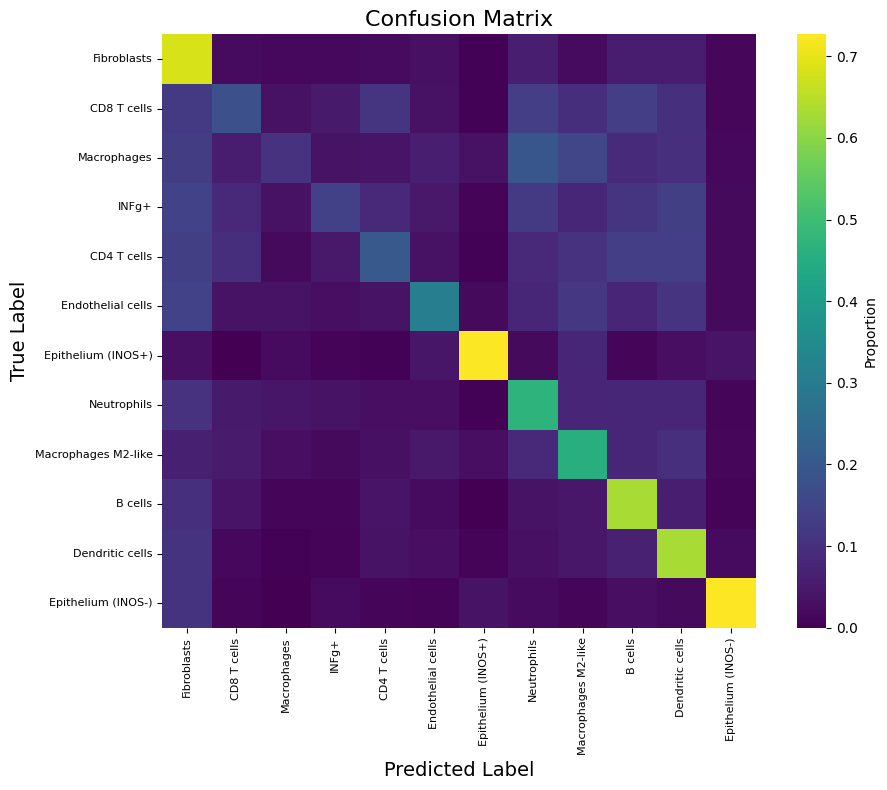


L1 lineage (L2→L1 agg)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level1.pdf


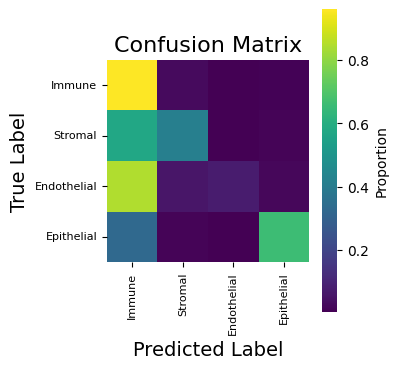


L1 lineage (L1 head)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level1_L1head.pdf


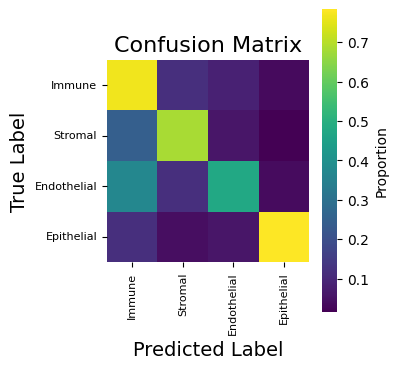


L12 sublineage
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level12.pdf


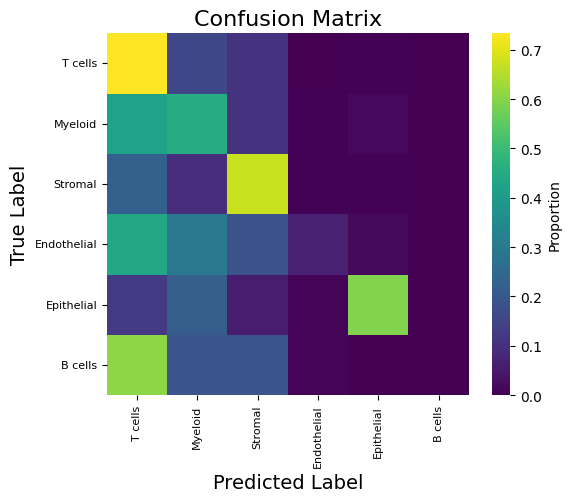

Skip L3 CNiche: no val_preds_level3 (re-run ablation cell after reload model/base)
Skip L4 TNiche: no val_preds_level4 (re-run ablation cell after reload model/base)
L1 agg vs L1 head agreement: 0.7500983745497473


In [ ]:
# In-sample confusion matrices for every label tier (best-fold model in LP)
if isinstance(globals().get("LP"), dict) and LP.get("model") is not None:
    ensure_lp_extra_insample_preds(
        LP["model"],
        scaler,
        cv_data,
        device,
        predict_all_label_heads,
        globals(),
        neighbor_index=globals().get("spatial_neighbor_index"),
    )
plot_he_confusion_matrices(plot_confusion_matrix, result_fig, cv_data, globals())


In [ ]:
## Save validation metrics: CV fold means + in-sample per tier (L2/L1/L12)
import numpy as np

logo_summary = globals().get("logo_summary")
if logo_summary is None and isinstance(globals().get("LP"), dict):
    logo_summary = LP.get("logo_summary")
if logo_summary is None:
    raise NameError("Run the ablation / CV cell first (globals().update(LP)) to define logo_summary.")

metrics_csv_path = result_fig("validation_internal_metrics")

hce_w1_used = globals().get("hce_w1", 1.0)
hce_w2_used = globals().get("hce_w2", 1.0)
hce_w12_used = globals().get("hce_w12", 2.0)
hce_w_l12head_used = globals().get("hce_w_l12head", 1.0)
hce_w_l3_used = globals().get("hce_w_l3", 1.0)
hce_w_l4_used = globals().get("hce_w_l4", 1.0)
mean_best_epoch = int(round(float(np.mean([f["best_epoch"] for f in logo_summary["folds"]]))))

insample_tiers, _num_classes = build_insample_tier_metrics(globals(), cv_data if "cv_data" in globals() else None)

tier_extra = collect_hce_tier_metrics_extras(
    logo_summary=logo_summary,
    insample=insample_tiers,
    num_classes=_num_classes,
)

_l2_ins = insample_tiers.get("l2") or {}
_l1_ins = insample_tiers.get("l1") or {}

metrics_df, combined_df = save_hce_validation_metrics(
    val_acc=_l2_ins.get("accuracy", float("nan")),
    val_macro_f1=logo_summary["l2_macro_f1_mean"],
    val_weighted_f1=logo_summary["l2_weighted_f1_mean"],
    val_level1_acc=_l1_ins.get("accuracy", float("nan")),
    val_level1_macro_f1=logo_summary["l1_macro_f1_mean"],
    val_level1_weighted_f1=logo_summary["l1_weighted_f1_mean"],
    class_names=class_names if "class_names" in globals() else None,
    class_names_level1=class_names_level1 if "class_names_level1" in globals() else None,
    best_epoch=mean_best_epoch,
    hce_lambda=None,
    hce_w1=hce_w1_used,
    hce_w2=hce_w2_used,
    hce_w12=hce_w12_used,
    hce_w_l12head=hce_w_l12head_used,
    hce_w_l3=hce_w_l3_used,
    hce_w_l4=hce_w_l4_used,
    therapy_data=f"{therapy_data}_kfold_CV",
    metrics_csv_path=metrics_csv_path,
    extra_metrics=tier_extra,
)

print("\nPer-tier columns in CSV (cv_* = fold mean, insample_* = all cells, best-fold model):")
_tier_cols = [c for c in combined_df.columns if c.startswith(("cv_", "insample_", "num_"))]
print(combined_df[_tier_cols].tail(1).T)


Current run metrics:
             timestamp                         therapy_data  best_epoch  \
0  2026-08-11 17:48:51  awy-98938_aligned_0d535a74_kfold_CV           6   

  hce_lambda  hce_w1  hce_w2  hce_w12  hce_w_l12head  hce_w_l3  hce_w_l4  ...  \
0       None     1.0     2.0      1.0            1.0       1.0       1.0  ...   

   insample_l1_macro_f1  insample_l1_weighted_f1  insample_l1_head_accuracy  \
0              0.563946                 0.723834                   0.729788   

   insample_l1_head_macro_f1  insample_l1_head_weighted_f1  \
0                   0.636893                      0.739395   

   insample_l12_accuracy  insample_l12_macro_f1  insample_l12_weighted_f1  \
0               0.593214               0.432059                  0.572305   

   num_l1_head_classes  num_l12_classes  
0                    4                6  

[1 rows x 56 columns]

Saved comparison table to: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-989

Visualizing per-class performance...
  ✓ Computed metrics for 12 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_perclass_level2.pdf


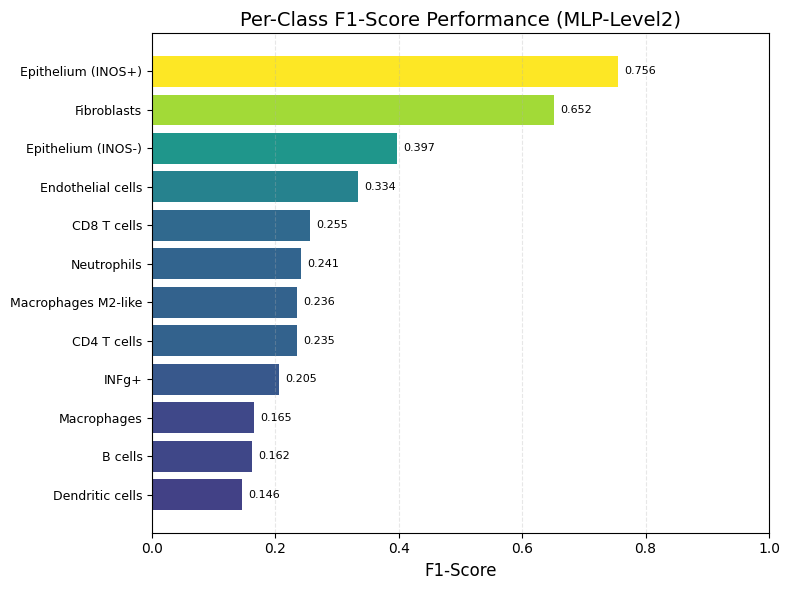


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 12
  Actual classes in test set: 12
  Feature dimension: 1024
  Model parameters: 1,714,966
  Best epoch: 7
  Test Accuracy: 0.3534
  Test Macro F1: 0.3154
  Test Weighted F1: 0.3525
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_perclass_level1.pdf


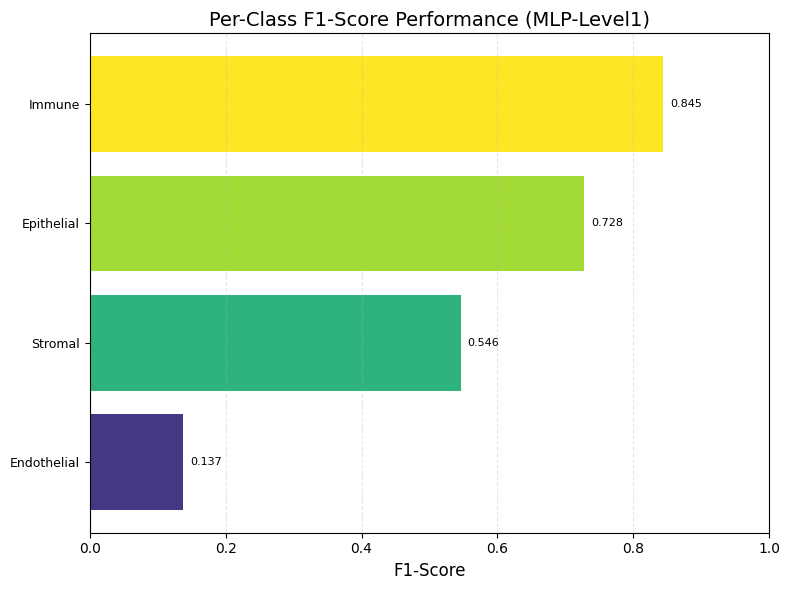


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Feature dimension: 1024
  Model parameters: 1,714,966
  Best epoch: 7
  Test Accuracy: 0.7614
  Test Macro F1: 0.5639
  Test Weighted F1: 0.7238
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_perclass_level1_L1head.pdf


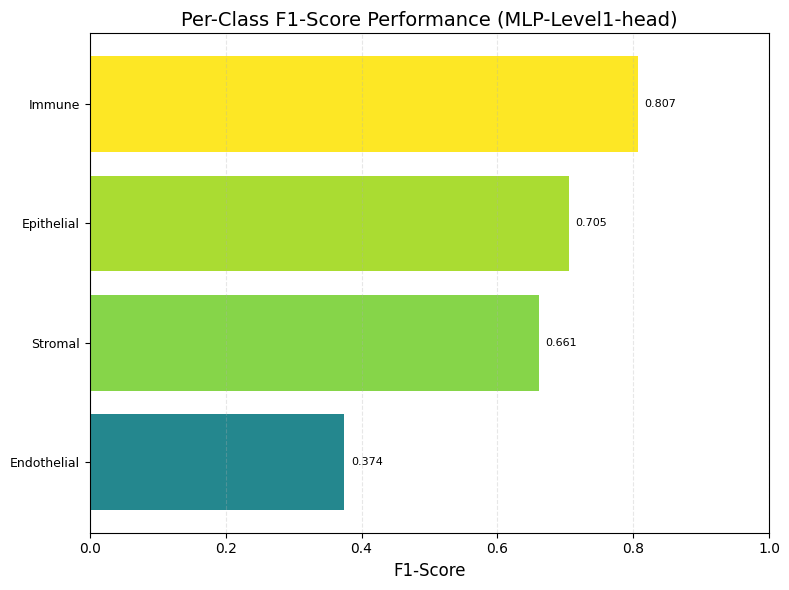


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Feature dimension: 1024
  Model parameters: 1,714,966
  Best epoch: 7
  Test Accuracy: 0.7614
  Test Macro F1: 0.5639
  Test Weighted F1: 0.7238

L12 sublineage
Visualizing per-class performance...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_perclass_level12.pdf


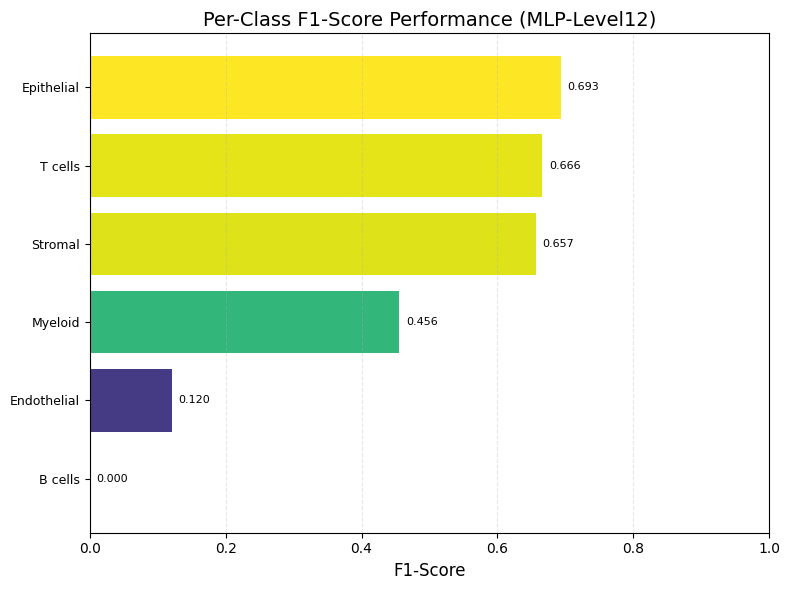


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Feature dimension: 1024
  Model parameters: 1,714,966
  Best epoch: 7
  Test Accuracy: 0.5932
  Test Macro F1: 0.4321
  Test Weighted F1: 0.5723
Skip L3 CNiche per-class F1: no val_preds_level3
Skip L4 TNiche per-class F1: no val_preds_level4


In [ ]:
# Per-class F1 for level2
metrics_df_level2 = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    y_sort_by="f1_asc",
    save_path=result_fig("f1_perclass_level2"),
)

metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    y_sort_by="f1_asc",
    save_path=result_fig("f1_perclass_level1"),
)

if globals().get("val_preds_level1_head") is not None:
    plot_per_class_f1(
        val_labels_level1,
        val_preds_level1_head,
        class_names_level1,
        model=model,
        device=device,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        input_dim=input_dim,
        best_epoch=best_epoch,
        test_acc=val_level1_acc,
        test_macro_f1=val_level1_macro_f1,
        test_weighted_f1=val_level1_weighted_f1,
        model_name="MLP-Level1-head",
        y_sort_by="f1_asc",
        save_path=result_fig("f1_perclass_level1_L1head"),
    )

if isinstance(globals().get("LP"), dict) and LP.get("model") is not None:
    ensure_lp_extra_insample_preds(
        LP["model"], scaler, cv_data, device, predict_all_label_heads, globals()
    )
plot_he_f1_extra_tiers(
    plot_per_class_f1,
    result_fig,
    model,
    device,
    train_dataset,
    val_dataset,
    input_dim,
    best_epoch,
    globals(),
)


  Using provided X and y...
  ✓ Using provided y strings as original labels for spatial TRUE plot.
  X_all_scaled shape: (33037, 1024)
  y_all_encoded shape: (33037,)
  ✓ Final y_all_encoded dtype: int64
X_all_scaled:  (33037, 1024)
y_all_encoded:  (33037,)
  Total samples: 33037
  DataLoader batch_size: 1024, num_workers: 4

Final Performance on All Data:
  Accuracy: 0.3535
  Macro F1-score: 0.3154
  Weighted F1-score: 0.3525
all_preds:  (33037,)
unique_labels:  (12,)

Detailed Classification Report:
  Number of classes: 12
                     precision    recall  f1-score   support

            B cells       0.09      0.63      0.16       474
        CD4 T cells       0.29      0.20      0.24      3096
        CD8 T cells       0.46      0.18      0.26      6176
    Dendritic cells       0.08      0.63      0.15       429
  Endothelial cells       0.36      0.31      0.33      2186
 Epithelium (INOS+)       0.79      0.72      0.76      1780
 Epithelium (INOS-)       0.27      0.73 

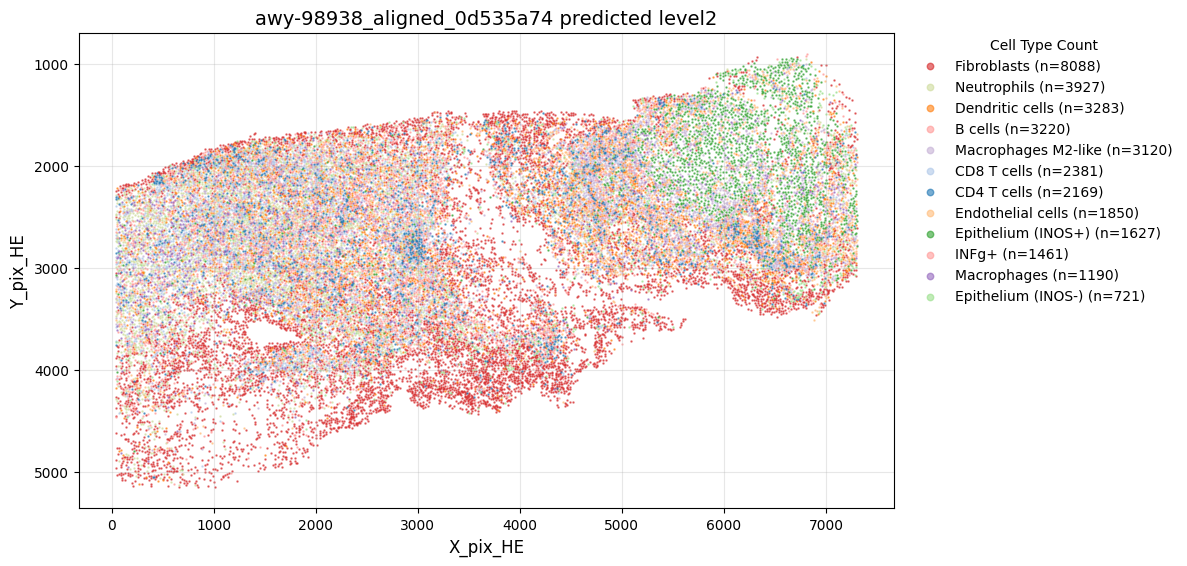


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 33037
Number of cell types: 12


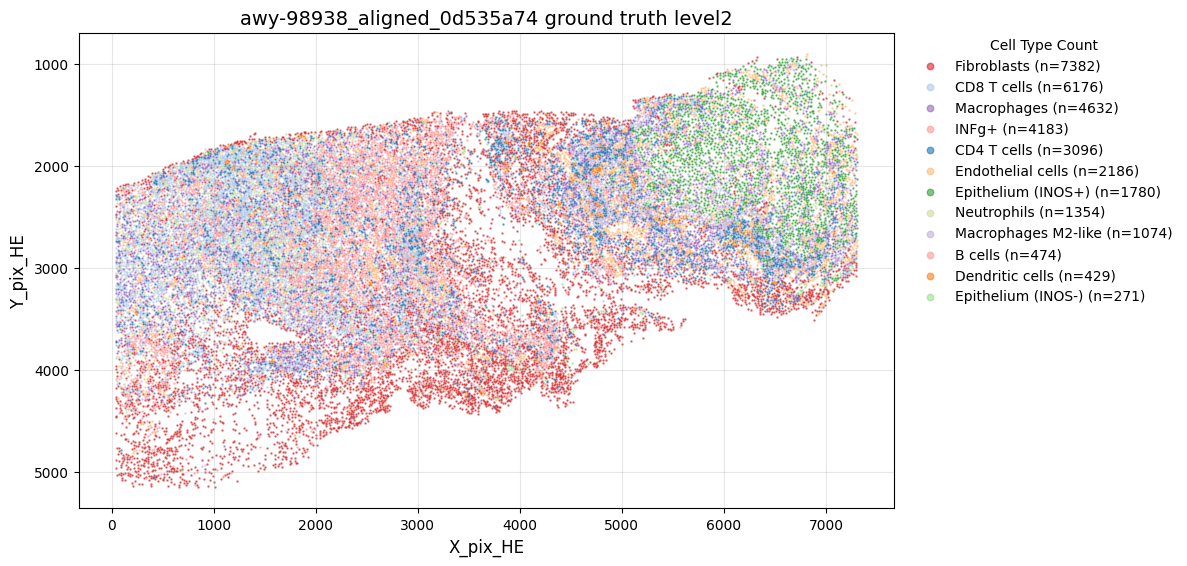

In [ ]:
## Evaluate on all data: level2 spatial — predicted vs ground truth
# Rows must match cv_data filter and scaler fit on X_f.
# When use_spatial_context=True, pass neighbor_index from build_spatial_neighbor_index.
_nbr = globals().get("spatial_neighbor_index")
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path="",
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if "val_loader" in globals() else None,
    X=cv_data["X_f"],
    y=cv_data["y_f"],
    y_encoded=cv_data["y_encoded_f"],
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    celltype_pred_dir=result_fig("celltype_valid_level2"),
    celltype_true_dir=result_fig("celltype_true_level2"),
    spatial_plot_mode="pred_true_l2",
    spatial_color_scheme="xenium_ct",
    spatial_title_pred_l2=f"{therapy_data} predicted level2",
    spatial_title_true_l2=f"{therapy_data} ground truth level2",
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
    neighbor_index=_nbr,
)


  Level1 spatial plot: NCRT distinct palette for 2 class name(s).
Number of valid data points: 33037
Number of cell types: 4


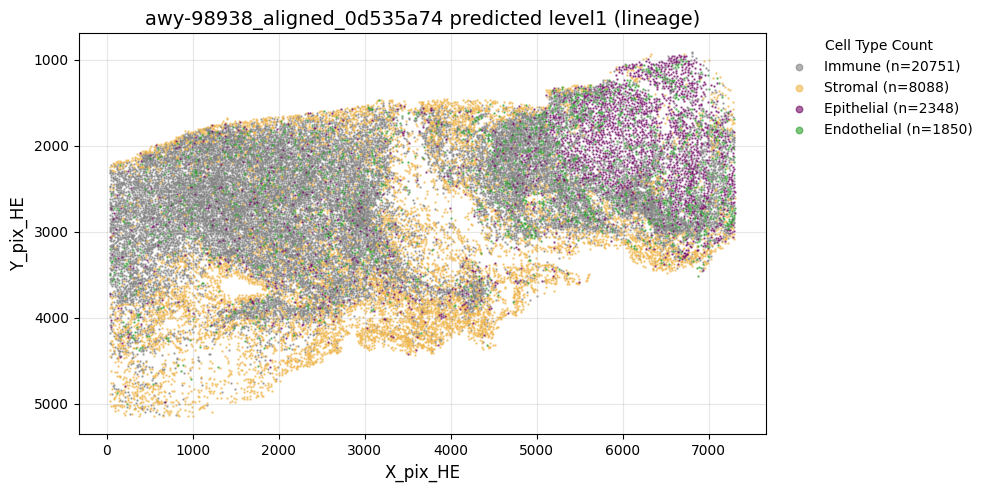

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_valid_level1.jpg
Number of valid data points: 33037
Number of cell types: 4


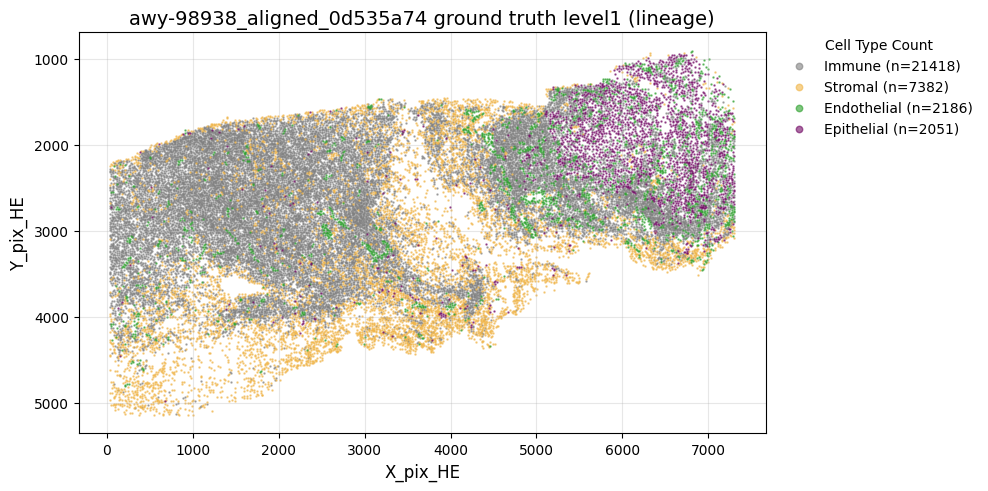

  Saved level1 true spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_true_level1.jpg


In [ ]:
plot_level1_spatial_distribution(
    matched_features_path=matched_features_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=result_fig("celltype_valid_level1"),
    save_path_true=result_fig("celltype_true_level1"),
    spatial_color_scheme="ncrt",
    title_pred=f"{therapy_data} predicted level1 (lineage)",
    title_true=f"{therapy_data} ground truth level1 (lineage)",
    fig_size=(10, 8),
    show=True,
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    y_level1_f=cv_data["y_level1_f"],
)



L12 sublineage
Number of valid data points: 33037
Number of cell types: 5


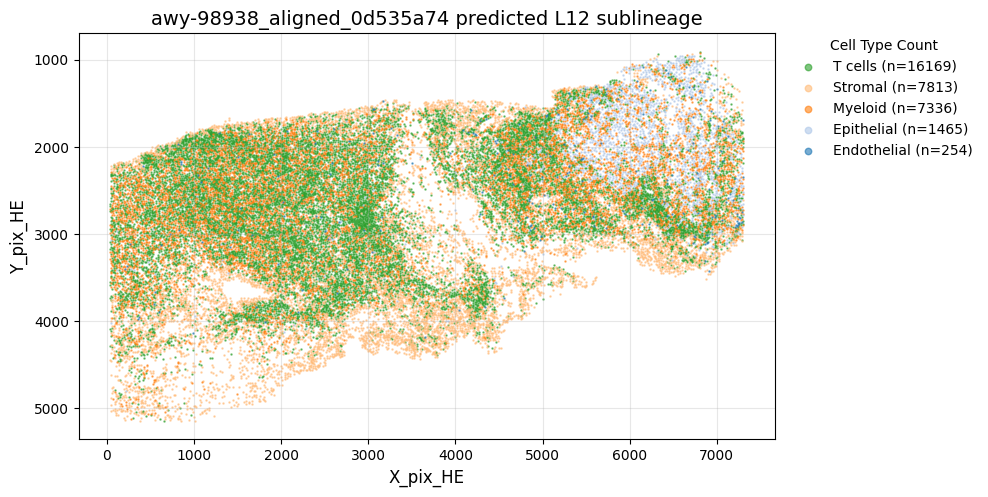

  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_valid_level12.jpg
Number of valid data points: 33037
Number of cell types: 6


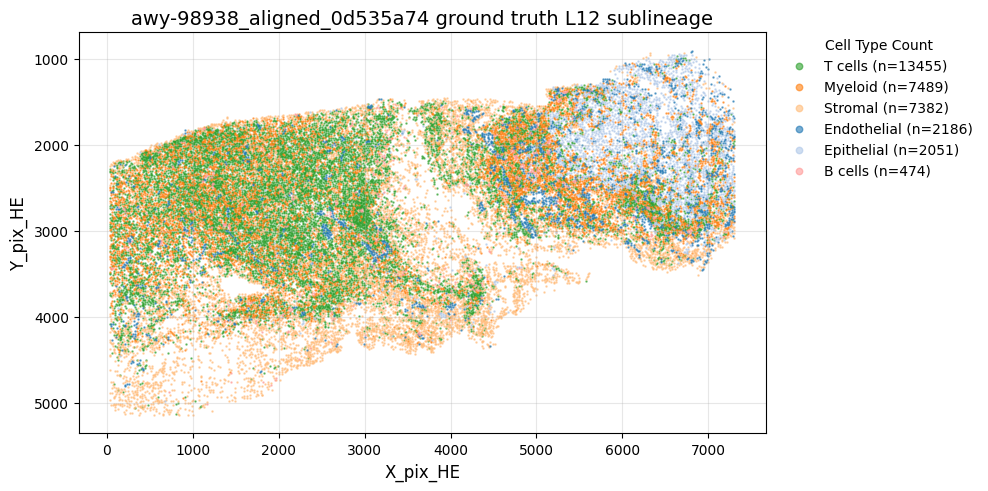

  Saved ground-truth spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_true_level12.jpg
Skip L3 CNiche spatial: no val_preds_level3
Skip L4 TNiche spatial: no val_preds_level4


In [ ]:
## L12 intermediate hierarchy spatial — predicted vs ground truth
if isinstance(globals().get("LP"), dict) and LP.get("model") is not None:
    ensure_lp_extra_insample_preds(
        LP["model"],
        scaler,
        cv_data,
        device,
        predict_all_label_heads,
        globals(),
        neighbor_index=globals().get("spatial_neighbor_index"),
    )
plot_he_spatial_extra_tiers(
    plot_tier_spatial_distribution,
    plot_celltype_spatial_distribution,
    result_fig,
    therapy_data,
    X_coords_plot if "X_coords_plot" in globals() else None,
    cv_data if "cv_data" in globals() else None,
    globals(),
)


## Predict StarDist

In [ ]:
## Load best model for StarDist prediction.
_star_ckpt = globals().get("BEST_MLP_CHECKPOINT")
if _star_ckpt is None and isinstance(globals().get("LP"), dict):
    _bf = LP.get("best_fold")
    if isinstance(_bf, dict):
        _star_ckpt = _bf.get("checkpoint")
if _star_ckpt is None:
    _cand = BEST_MLP_PATH if "BEST_MLP_PATH" in globals() else get_select4_best_checkpoint_path(path, therapy_data, therapy_model)
    if os.path.isfile(_cand):
        _star_ckpt = _cand

model_star = load_model_for_predict(
    path,
    therapy_data,
    therapy_model,
    parent_dir=True,
    checkpoint_path=_star_ckpt,
    device=device if "device" in globals() else None,
)


Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/best_mlp_gpu.pt
  Inferred hidden_dims from checkpoint: [1024, 512, 256]
✓ StarDist model loaded


In [ ]:
## StarDist matched features for CODEX HCC
# StarDist centroids: prepared CSV under data/CODEX/HCC/StarDist_Segment only
#   (do not rebuild from ImgEmbeddings_all_stardist/*.pth filenames).
# GT→StarDist cell table is prebuilt by match_codex_cells_with_pixel.py:
#   {SAMPLE_DIR}/{therapy_data}_cells_matched_by_stardist.csv
# This cell only builds matched_features_stardist.h5ad (generate once; reuse when present).

hist_embedding_stardist_dir = Path(f'{MODEL_DIR}/ImgEmbeddings_all_stardist/sc_pth_16_16')
stardist_raw_path = Path(globals().get(
    'stardist_raw_path',
    Path(STARDIST_ROOT) / therapy_data / f'{therapy_data}_Float_prob0.01_nms_0.3.csv',
))
if not stardist_raw_path.is_file():
    raise FileNotFoundError(
        "Prepared StarDist CSV not found under StarDist_Segment.\n"
        f"Expected: {stardist_raw_path}"
    )
print('stardist_raw_path =', stardist_raw_path)

celltype_pixel_stardist_path = globals().get(
    'celltype_pixel_stardist_path',
    f'{SAMPLE_DIR}/{therapy_data}_cells_matched_by_stardist.csv',
)
matched_features_stardist_path = f'{SAMPLE_DIR}/{therapy_data}_matched_features_stardist.h5ad'
pth_prefix_stardist = f'sc_{therapy_data}'  # StarDist UNI files use HE key, not acq_id

if not Path(celltype_pixel_stardist_path).is_file():
    raise FileNotFoundError(
        f"Missing preprocessed StarDist-matched table: {celltype_pixel_stardist_path}\n"
        "Run: conda run -n SeededNTM python code/CODEX_hcc/match_codex_cells_with_pixel.py "
        f"--he-key {therapy_data}"
    )
print(f'Using preprocessed StarDist-matched cells: {celltype_pixel_stardist_path}')

level1_name = globals().get('level1_name', 'celltype_level1')
_column_rename = globals().get('column_rename', {
    'final_CT': 'celltype',
    'final_sublineage': 'celltype_level12',
    'final_lineage': 'celltype_level1',
})
match_tolerance = 1.0

# Build StarDist matched h5ad once. Set True only after changing CSV / embeddings.
FORCE_REBUILD_STARDIST_H5AD = False
if not Path(matched_features_stardist_path).is_file():
    FORCE_REBUILD_STARDIST_H5AD = True
print(f'FORCE_REBUILD_STARDIST_H5AD = {FORCE_REBUILD_STARDIST_H5AD}')

adata_star = match_hist2cell_h5ad(
    cell_coords_path=celltype_pixel_stardist_path,
    hist_embedding_dir=hist_embedding_stardist_dir,
    matched_h5ad_path=matched_features_stardist_path,
    coord_cols=('centroid_x', 'centroid_y'),
    tolerance=match_tolerance,
    pth_prefix=pth_prefix_stardist,
    level1_name=level1_name,
    column_rename=_column_rename,
    auto_rename=False,
    force_rebuild=FORCE_REBUILD_STARDIST_H5AD,
    obs_columns=base.HCC_H5AD_OBS_COLUMNS,
    spatial_cols=('centroid_x', 'centroid_y'),
    spatial_he_cols=('X_pix_HE', 'Y_pix_HE'),
    cell_id_col='cell_id',
)
print(adata_star)
print('obs columns:', list(adata_star.obs.columns))
print('obsm keys:', list(adata_star.obsm.keys()))

# Backward-compatible names for downstream StarDist cells
X_star = adata_X_to_dense(adata_star.X)
y_star = adata_star.obs['final_CT'].to_numpy()
y_star_level1 = adata_star.obs['final_lineage'].to_numpy()
y_star_level12 = adata_star.obs['final_sublineage'].to_numpy()
y_star_level3 = y_star_level4 = None
X_coords_star = adata_star.obsm['spatial']

# StarDist spatial kNN (for models trained with use_spatial_context)
spatial_neighbor_index_star = None
if use_spatial_context:
    spatial_neighbor_index_star = build_spatial_neighbor_index(
        np.asarray(X_coords_star), k_neighbors=spatial_k
    )
    print(
        f"StarDist spatial context: k={spatial_k}, mode={spatial_mode!r}, "
        f"neighbor_index shape={spatial_neighbor_index_star.shape}"
    )


stardist_raw_path = /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_Float_prob0.01_nms_0.3.csv
Loading celltype Ground Truth ...
  Column rename applied: {'final_CT': 'celltype', 'final_sublineage': 'celltype_level12', 'final_lineage': 'celltype_level1'}
  Loaded 33060 cells
  Cell types: 12 unique types

celltype_pixel_coords shape: (33060, 2)
stardist_pixel_coords shape: (42877, 2)
Building KDTree for star_coords...
Finding 100 nearest neighbors for each celltype point...
Nearest neighbor search completed. Distance matrix shape: (33060, 100)

Using greedy nearest neighbor matching...
Matched 32993 points
Matched distance: Mean, Median, Max: 8.81, 4.94, 193.81

Matched points summary:
  Total points in celltype_pixel_coords: 33060
  Matched points: 32993
  Unmatched points: 67
Matched of PCF-HE-StarDist: (32993, 13)
Saved StarDist matched cells: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HC

Loading .pth files (workers=16): 100%|██████████| 42877/42877 [00:43<00:00, 981.66it/s] 


  Successfully loaded 42877 embeddings
  Embedding dimension: (1024,)

Matching embeddings with celltype data (this may take a few minutes)...
  Using specified coordinates: centroid_x, centroid_y
  Building KDTree for embeddings: 42,877 points
  KDTree matched 32,993 / 32,993 cells (100.00%).
  Matched 32993 cells out of 32993
  Match rate: 100.00%
  ✓ Saved matched h5ad to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features_stardist.h5ad (32,993 cells × 1024 features)
AnnData object with n_obs × n_vars = 32993 × 1024
    obs: 'final_CT', 'final_lineage', 'final_sublineage', 'tma'
    uns: 'cell_coords_path', 'matched_n_cells', 'embedding_dim'
    obsm: 'spatial', 'spatial_HE'
obs columns: ['final_CT', 'final_lineage', 'final_sublineage', 'tma']
obsm keys: ['spatial', 'spatial_HE']


  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features_stardist.h5ad: (32993, 1024)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features_stardist.h5ad: (32993,), dtype: object
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (32993, 1024)
  No labels available - prediction mode only
X_all_scaled:  (32993, 1024)
dummy_labels:  (32993,)
  Total samples: 32993
  DataLoader batch_size: 1024, num_workers: 4
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 33/33 [00:00<00:00, 75.36it/s]



Prediction completed:
  Total predictions: 32993
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11]
  ✓ Using original labels for visualization: 32993 labels
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.2795, macro_f1=0.2192, weighted_f1=0.2839

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/awy-98938_aligned_0d535a74_matched_features_stardist.h5ad: (32993, 2)
  Coordinates shape: (32993, 2)
  Predictions shape: (32993,)
  ✓ Created prediction DataFrame with 32993 cells

Plotting spatial distribution of PREDICTED level2 cell types...
Number of valid data points: 32993
Number of cell types: 12


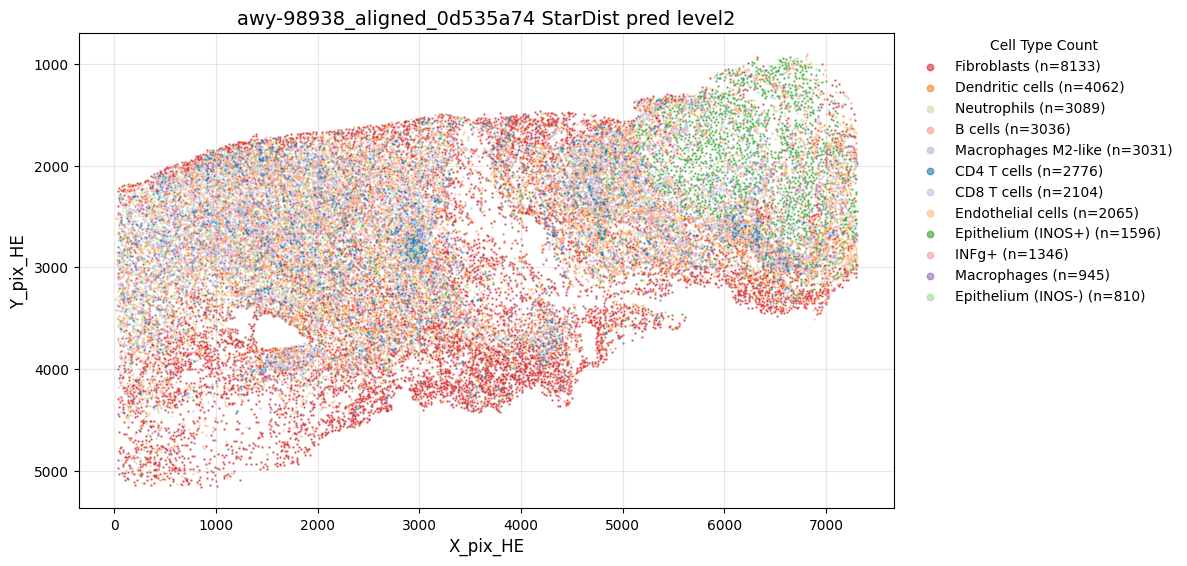


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 32993
Number of cell types: 12


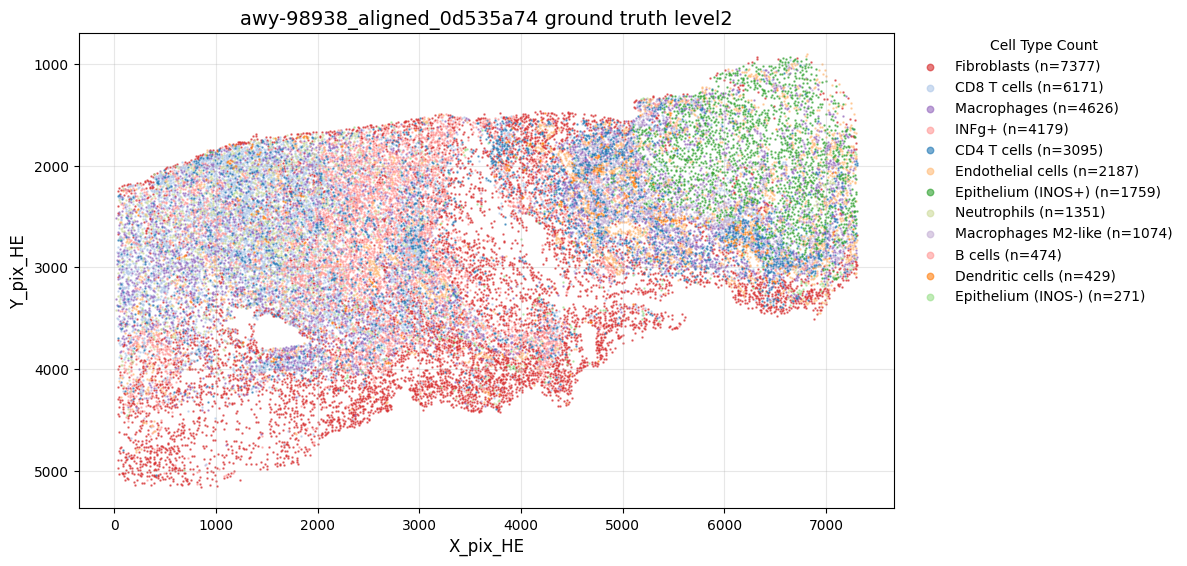

In [ ]:
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

_nbr_star = globals().get("spatial_neighbor_index_star")
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model_star,
    matched_features_path=matched_features_stardist_path,
    class_names=class_names_star,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=None,
    prediction_only=True,
    X_coords_matched=X_coords_star if "X_coords_star" in globals() else None,
    y_level1_f=y_star_level1 if "y_star_level1" in globals() else None,
    celltype_pred_dir=result_fig("stardist_pred_level2"),
    # celltype_true_dir=result_fig("stardist_true_level2"),
    spatial_plot_mode="pred_true_l2",
    spatial_color_scheme="xenium_ct",
    spatial_title_pred_l2=f"{therapy_data} StarDist pred level2",
    spatial_title_true_l2=f"{therapy_data} ground truth level2",
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
    neighbor_index=_nbr_star,
)


  Level1 spatial plot: NCRT distinct palette for 2 class name(s).
Number of valid data points: 32993
Number of cell types: 4


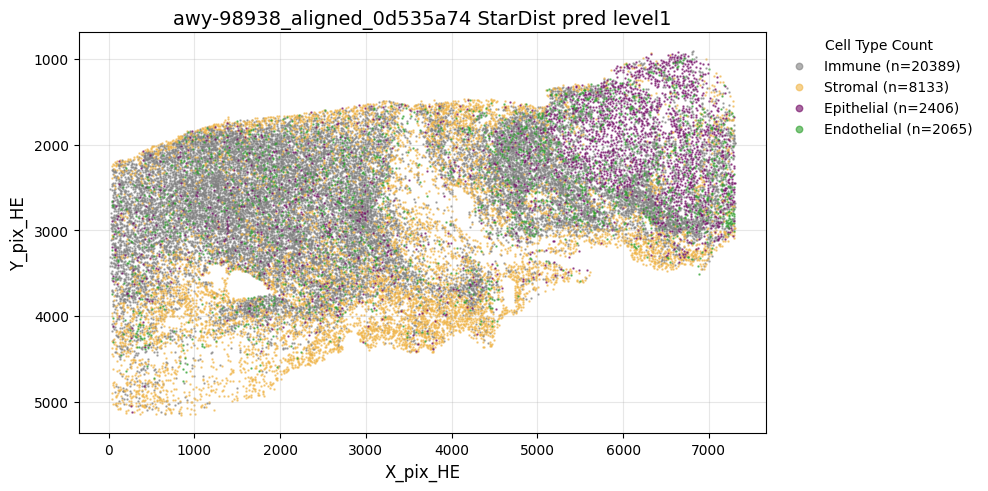

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_pred_stardist_level1.jpg
Number of valid data points: 32993
Number of cell types: 4


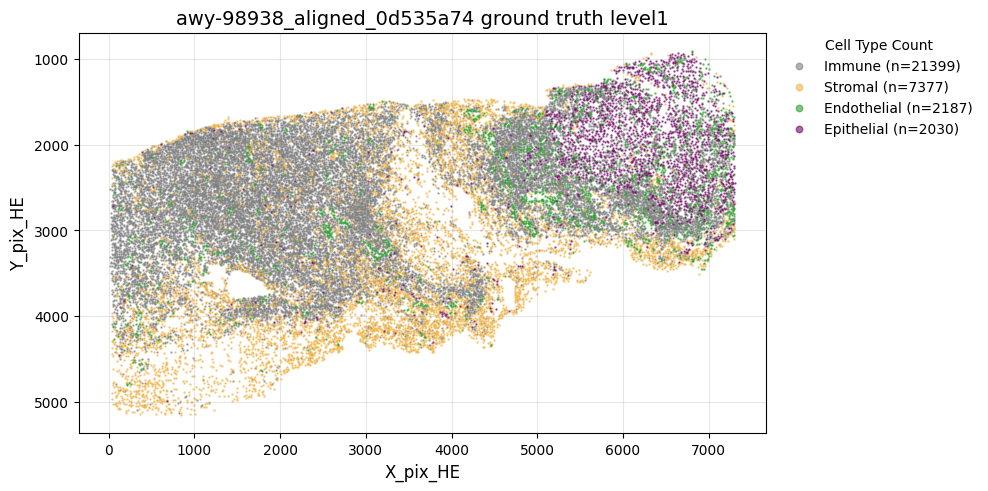

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_pred_stardist_level1.jpg


In [ ]:
# L2→L1 mapping comes from HE cv_data (same class_names / le_* as the trained model).
# Do not le_level2.transform(y_star): StarDist matched cells can include CT labels absent from training.
plot_level1_spatial_distribution(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=result_fig("stardist_pred_level1"),
    # save_path_true=result_fig("stardist_true_level1"),
    spatial_color_scheme="ncrt",
    fig_size=(10, 8),
    show=True,
    X_coords_matched=X_coords_star,
    y_level1_f=y_star_level1,
    spatial_title_pred_l1=f"{therapy_data} StarDist pred level1",
    spatial_title_true_l1=f"{therapy_data} ground truth level1",
)
print(f"Saved: {result_fig('stardist_pred_level1')}")



L12 sublineage (StarDist)
Number of valid data points: 32993
Number of cell types: 5


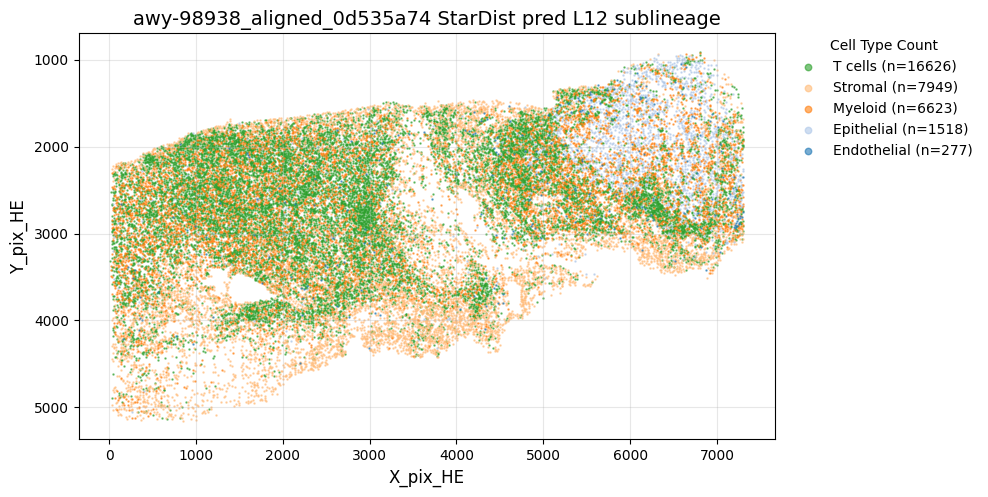

  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_pred_stardist_level12.jpg
Number of valid data points: 32993
Number of cell types: 6


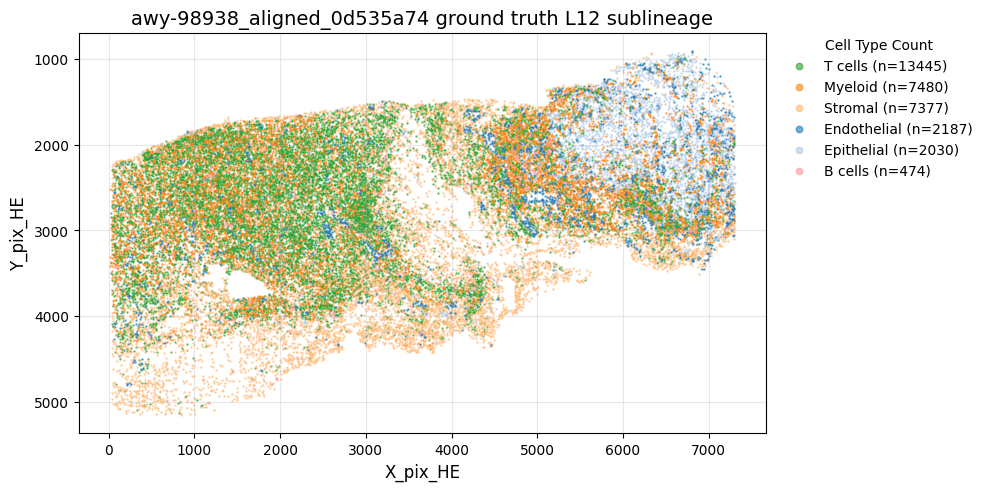

  Saved ground-truth spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_true_stardist_level12.jpg
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/celltype_pred_stardist_level12.jpg
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [ ]:
## StarDist: L12 intermediate hierarchy spatial — predicted vs ground truth
if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 spatial: model_star is not five-head / three-head.")
else:
    _star_heads = stardist_head_preds(
        model_star,
        scaler,
        X_star,
        device,
        predict_all_label_heads,
        neighbor_index=globals().get("spatial_neighbor_index_star"),
    )
    plot_stardist_spatial_extra(
        plot_tier_spatial_distribution,
        plot_celltype_spatial_distribution,
        result_fig,
        therapy_data,
        X_coords_star,
        _star_heads,
        cv_data if "cv_data" in globals() else None,
        globals(),
    )


Visualizing per-class accuracy...
  ✓ Computed metrics for 12 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level2_stardist.pdf


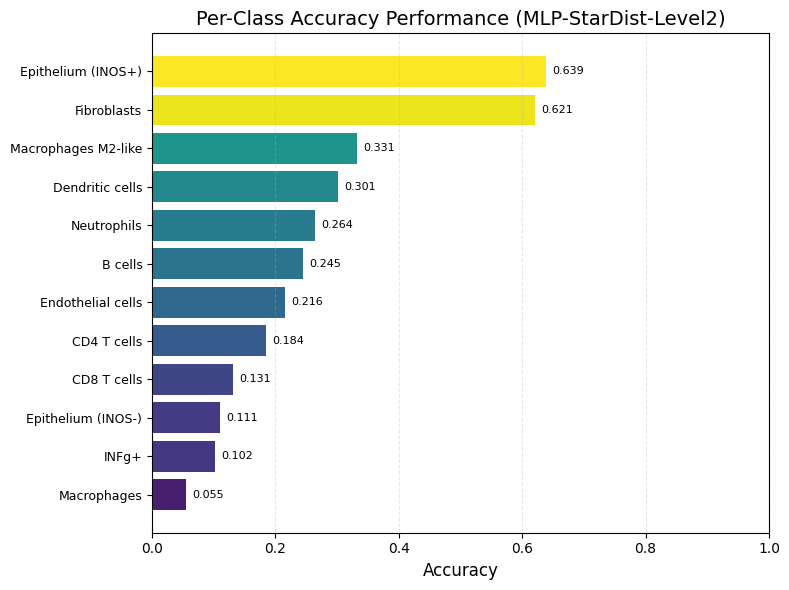


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 12
  Actual classes in test set: 12
  Model parameters: 1,714,966
  Test Accuracy: 0.2795
  Test Macro F1: 0.2192
  Test Weighted F1: 0.2839
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level2_stardist.pdf
  Level1 metrics from level2 preds: acc=0.6885, macro_f1=0.5402, weighted_f1=0.6910
Visualizing per-class accuracy...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level1_stardist.pdf


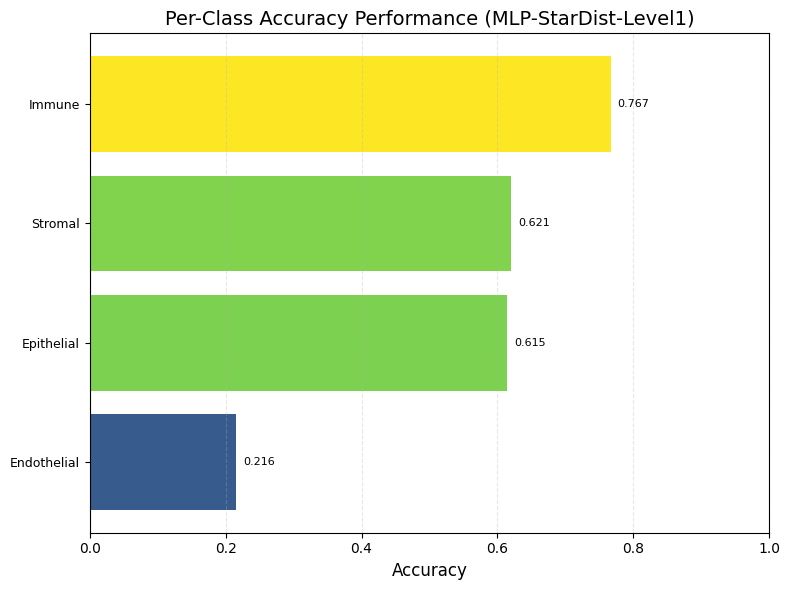


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,714,966
  Test Accuracy: 0.6885
  Test Macro F1: 0.5402
  Test Weighted F1: 0.6910
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level1_stardist.pdf
  Level1 metrics from L1 head: acc=0.6684, macro_f1=0.5466, weighted_f1=0.6833
Visualizing per-class accuracy...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level1_stardist_L1head.pdf


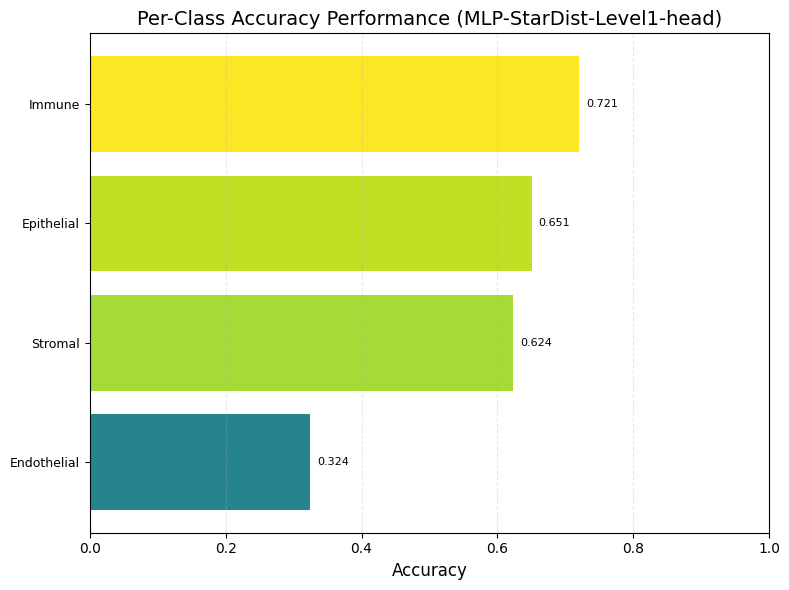


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,714,966
  Test Accuracy: 0.6684
  Test Macro F1: 0.5466
  Test Weighted F1: 0.6833
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level1_stardist_L1head.pdf

L12 sublineage (StarDist): acc=0.5445, macro_f1=0.3881
Visualizing per-class accuracy...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level12_stardist.pdf


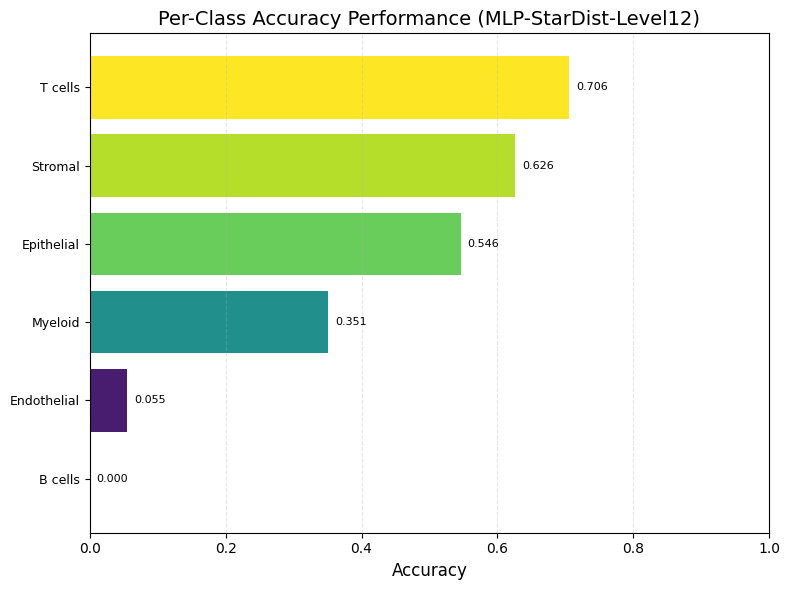


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Model parameters: 1,714,966
  Test Accuracy: 0.5445
  Test Macro F1: 0.3881
  Test Weighted F1: 0.5213
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/acc_level12_stardist.pdf
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [ ]:
## StarDist per-class accuracy (run after StarDist evaluate cell)
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

metrics_acc_star = plot_per_class_accuracy(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    model_name="MLP-StarDist-Level2",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level2_stardist"),
)
print(f"Saved: {result_fig('acc_level2_stardist')}")

metrics_acc_star_l1 = plot_level1_accuracy_from_level2_predictions(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_accuracy=plot_per_class_accuracy,
    model=model_star,
    device=device,
    model_name="MLP-StarDist-Level1",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level1_stardist"),
)
if metrics_acc_star_l1 is not None:
    print(f"Saved: {result_fig('acc_level1_stardist')}")

metrics_acc_star_l1_head = plot_level1_accuracy_from_level1_head(
    matched_features_path=matched_features_stardist_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_accuracy=plot_per_class_accuracy,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    model_name="MLP-StarDist-Level1-head",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level1_stardist_L1head"),
    neighbor_index=globals().get("spatial_neighbor_index_star"),
)
if metrics_acc_star_l1_head is not None:
    print(f"Saved: {result_fig('acc_level1_stardist_L1head')}")

if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 per-class accuracy: model_star is not five-head / three-head.")
else:
    _star_heads = stardist_head_preds(
        model_star,
        scaler,
        X_star,
        device,
        predict_all_label_heads,
        neighbor_index=globals().get("spatial_neighbor_index_star"),
    )
    plot_stardist_acc_extra(plot_per_class_accuracy, result_fig, model_star, device, _star_heads, cv_data if "cv_data" in globals() else None, globals())


Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level2_stardist.pdf


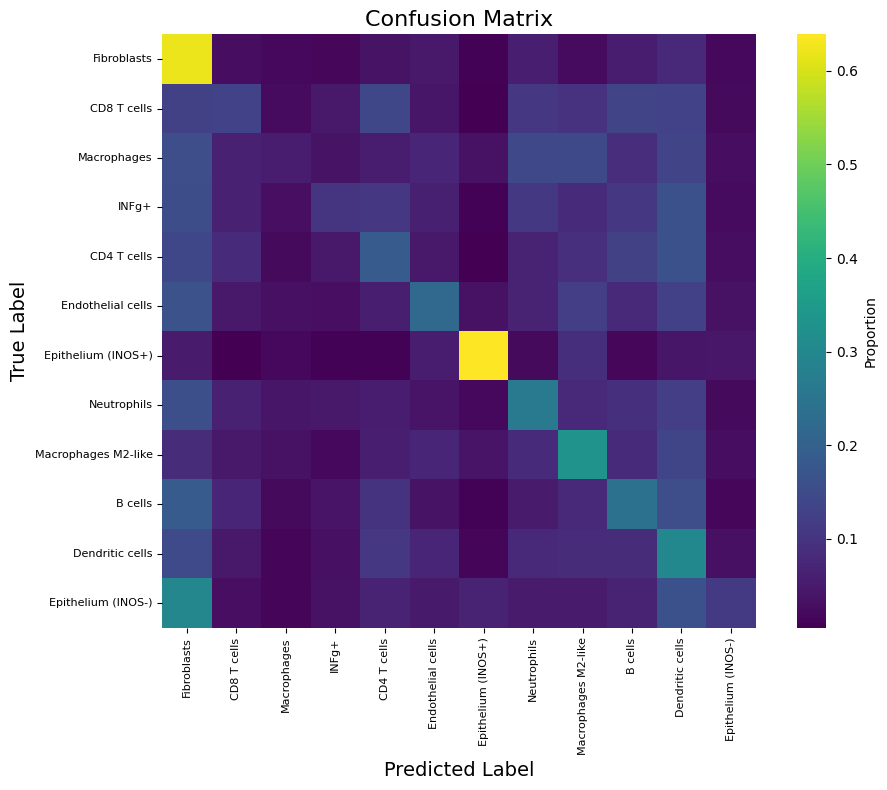

Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level1_stardist.pdf


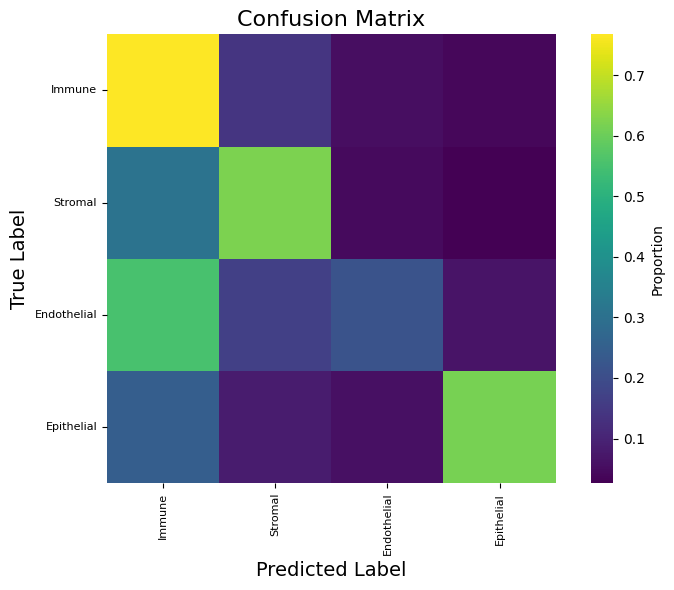


L12 sublineage (StarDist) confusion matrix
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level12_stardist.pdf


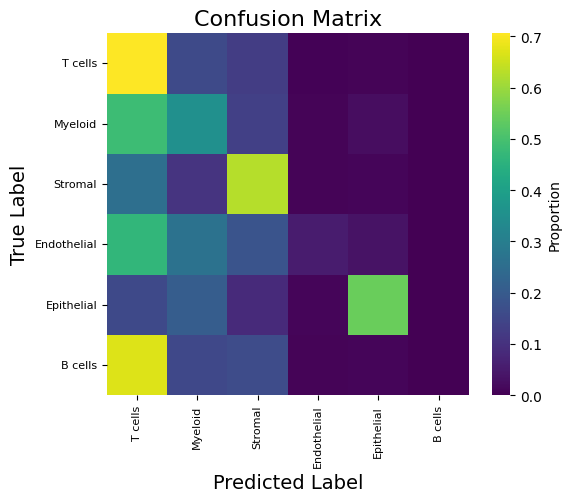

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/conf_matrix_level12_stardist.pdf
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [ ]:
# StarDist prediction heatmaps (confusion matrices): level2 + level1
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

plot_confusion_matrix(
    all_labels,
    all_preds,
    class_names_star,
    figsize=(10, 8),
    save_path=result_fig("conf_matrix_level2_stardist"),
)

_loaded_star = load_matched_features_bundle(matched_features_stardist_path)
if "y_level1" in _loaded_star:
    _preds_arr = np.asarray(all_preds, dtype=np.int64)
    _n = min(len(_preds_arr), len(_loaded_star["y_level1"]))
    _preds_arr = _preds_arr[:_n]
    _y_true_l1_raw = _loaded_star["y_level1"][:_n]
    _l2_ok = (_preds_arr >= 0) & (_preds_arr < len(class_names_star))
    _child_to_parent = np.full(len(class_names_star), -1, dtype=np.int64)
    for _l2, _l1 in zip(y_encoded_f, y_level1_encoded_f):
        _l2_i, _l1_i = int(_l2), int(_l1)
        if _child_to_parent[_l2_i] == -1:
            _child_to_parent[_l2_i] = _l1_i
    _preds_l1 = _child_to_parent[_preds_arr[_l2_ok]]
    _y_true_l1_raw = _y_true_l1_raw[_l2_ok]

    if getattr(_y_true_l1_raw, "dtype", None) is not None and _y_true_l1_raw.dtype.kind in ["U", "S", "O"]:
        _name_to_idx = {str(c): i for i, c in enumerate(class_names_level1)}
        _y_true_l1 = np.array([_name_to_idx.get(str(v), -1) for v in _y_true_l1_raw], dtype=np.int64)
    else:
        _y_true_l1 = np.asarray(_y_true_l1_raw, dtype=np.int64)

    _n = min(len(_y_true_l1), len(_preds_l1))
    _y_true_l1 = _y_true_l1[:_n]
    _preds_l1 = _preds_l1[:_n]
    _valid = _y_true_l1 >= 0

    if np.any(_valid):
        plot_confusion_matrix(
            _y_true_l1[_valid],
            _preds_l1[_valid],
            class_names_level1,
            figsize=(8, 6),
            save_path=result_fig("conf_matrix_level1_stardist"),
            # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level1_stardist_hce.pdf',
        )
    else:
        print("Skip level1 StarDist confusion matrix: no valid y_level1 labels.")
else:
    print(f"Skip level1 StarDist confusion matrix: y_level1 not found in {matched_features_stardist_path}")

if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 confusion matrices: model_star is not five-head.")
else:
    _star_heads = stardist_head_preds(model_star, scaler, X_star, device, predict_all_label_heads)
    plot_stardist_confusion_extra(plot_confusion_matrix, result_fig, _star_heads, cv_data if "cv_data" in globals() else None, globals())


Visualizing per-class performance...
  ✓ Computed metrics for 12 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_level2_stardist.pdf


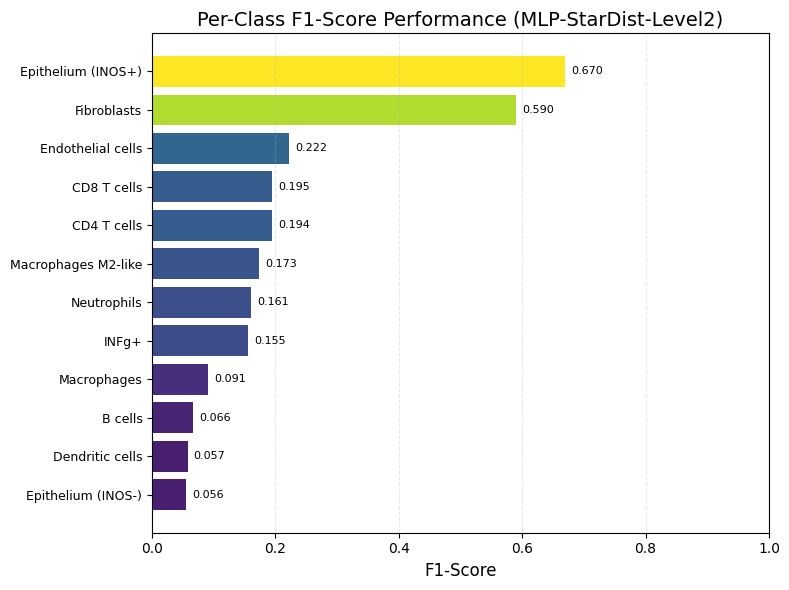


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 12
  Actual classes in test set: 12
  Model parameters: 1,714,966
  Test Accuracy: 0.2795
  Test Macro F1: 0.2192
  Test Weighted F1: 0.2839
  Level1 F1 plot from level2 preds (same mapping as accuracy helper): acc=0.6885, macro_f1=0.5402, weighted_f1=0.6910
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_level1_stardist.pdf


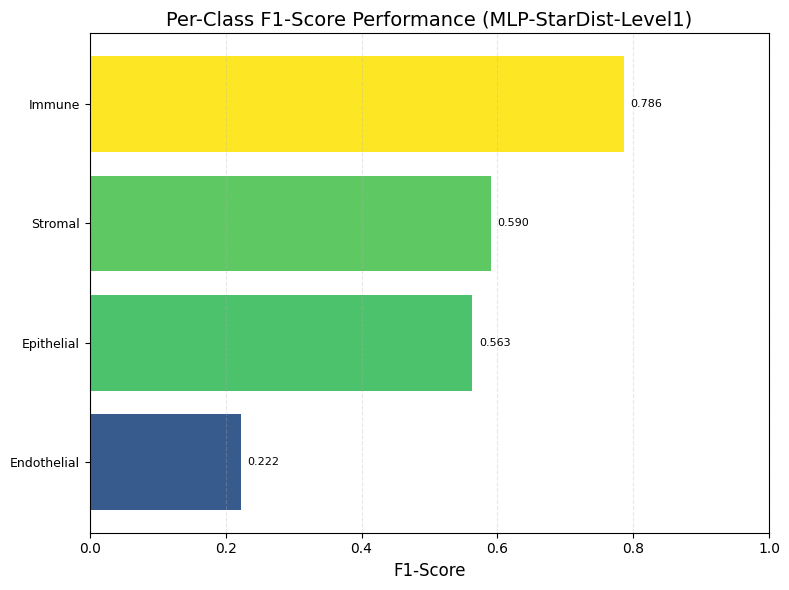


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,714,966
  Test Accuracy: 0.6885
  Test Macro F1: 0.5402
  Test Weighted F1: 0.6910
  Level1 F1 plot from L1 head: acc=0.6684, macro_f1=0.5466, weighted_f1=0.6833
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_level1_stardist_L1head.pdf


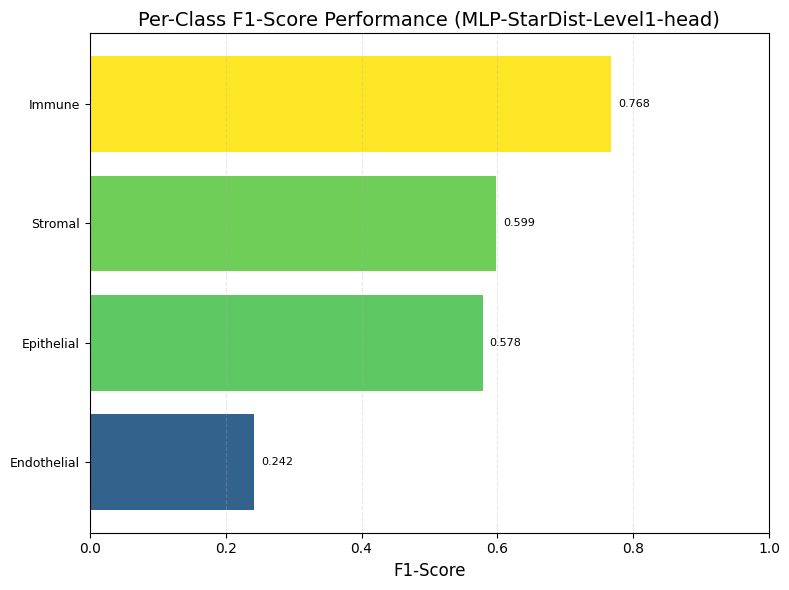


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,714,966
  Test Accuracy: 0.6684
  Test Macro F1: 0.5466
  Test Weighted F1: 0.6833

L12 sublineage (StarDist) per-class F1
Visualizing per-class performance...
  ✓ Computed metrics for 6 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_level12_stardist.pdf


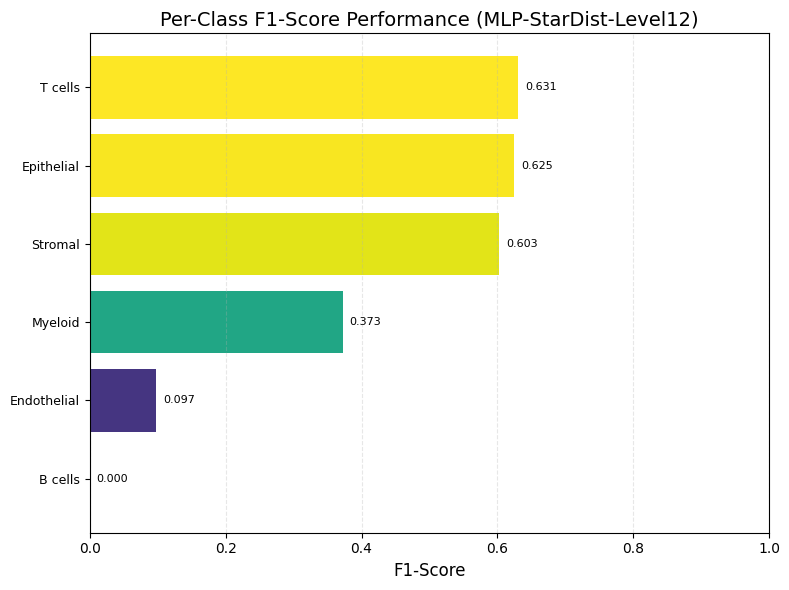


Model Summary:
  Device: cuda:0
  Total classes (before filtering): 6
  Actual classes in test set: 6
  Model parameters: 1,714,966
  Test Accuracy: 0.5445
  Test Macro F1: 0.3881
  Test Weighted F1: 0.5213
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/f1_level12_stardist.pdf
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4


In [ ]:
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

metrics_f1_star = plot_per_class_f1(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level2",
    save_path=result_fig("f1_level2_stardist"),
)

metrics_f1_star_l1 = plot_level1_f1_from_level2_predictions(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_f1=plot_per_class_f1,
    model=model_star,
    device=device,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level1",
    save_path=result_fig("f1_level1_stardist"),
)

metrics_f1_star_l1_head = plot_level1_f1_from_level1_head(
    matched_features_path=matched_features_stardist_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_f1=plot_per_class_f1,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level1-head",
    save_path=result_fig("f1_level1_stardist_L1head"),
    neighbor_index=globals().get("spatial_neighbor_index_star"),
)

if not hasattr(model_star, "level12_head"):
    print("Skip StarDist L12/L3/L4 per-class F1: model_star is not five-head / three-head.")
else:
    _star_heads = stardist_head_preds(
        model_star,
        scaler,
        X_star,
        device,
        predict_all_label_heads,
        neighbor_index=globals().get("spatial_neighbor_index_star"),
    )
    plot_stardist_f1_extra(plot_per_class_f1, result_fig, model_star, device, _star_heads, cv_data if "cv_data" in globals() else None, globals())


  ROC colors: xenium_ct (aligned with Xenium spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/roc_stardist_level2.pdf


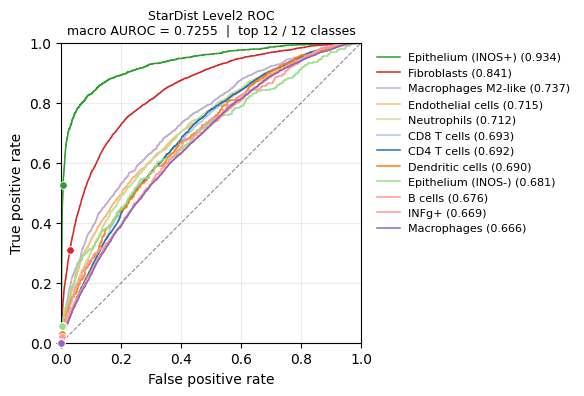

  ROC colors: xenium_lineage (aligned with Xenium spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/roc_stardist_level1.pdf


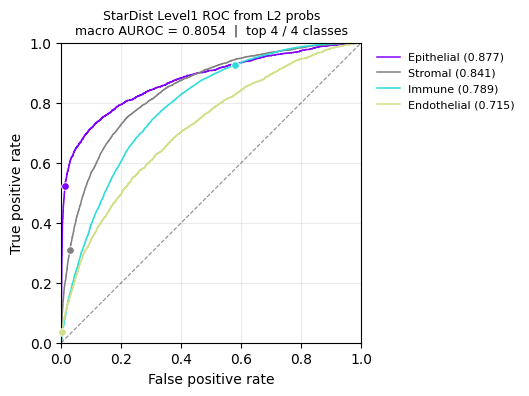

  ROC colors: xenium_lineage (aligned with Xenium spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/roc_stardist_level1_L1head.pdf


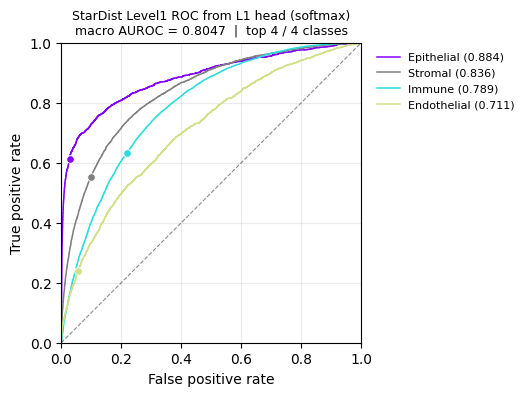


L12 sublineage (StarDist) ROC
  ROC colors: xenium_auto (aligned with Xenium spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/roc_stardist_level12.pdf


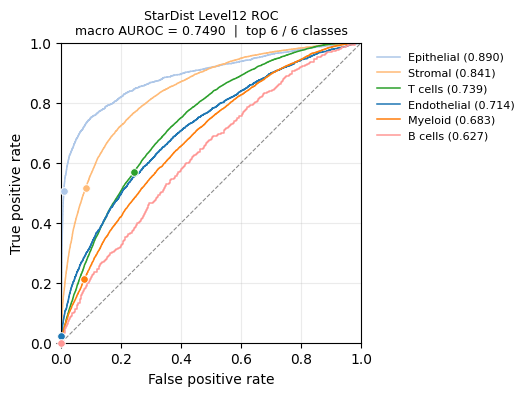

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/HCC/Michael_data_transfer/s4769/HE/awy-98938_aligned_0d535a74/project_all_UNI/result/roc_stardist_level12.pdf
Skip L3 CNiche ROC: missing probs l3
Skip L4 TNiche ROC: missing probs l4


In [ ]:
import numpy as np

class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

_z = load_matched_features_bundle(matched_features_stardist_path)
X_star_scaled = scaler.transform(_z["X"])
_nbr_star = globals().get("spatial_neighbor_index_star")
probs_l2 = mlp_collect_softmax_probs(
    model_star, X_star_scaled, device, neighbor_index=_nbr_star
)

# Full-length five-head softmax for metrics CSV (ROC plots use valid subset below).
_probs_heads = None
if hasattr(model_star, "level12_head"):
    _probs_heads = mlp_collect_five_head_softmax_probs(
        model_star, X_star_scaled, device, neighbor_index=_nbr_star
    )

# Encode y from the same bundle as probs (training class_names indices; unknown CT → -1).
if "y" not in _z:
    print("Skip ROC: no y in matched features bundle.")
else:
    y_roc = encode_labels_with_class_names(_z["y"], class_names_star)
    m = min(len(probs_l2), len(y_roc))
    probs_m = probs_l2[:m]
    y_m = y_roc[:m]
    valid = (y_m >= 0) & (y_m < len(class_names_star))
    n_bad = int((~valid).sum())
    if n_bad:
        print(
            f"  Excluding {n_bad} StarDist cells whose final_CT is absent from "
            f"training class_names ({len(class_names_star)} classes) for ROC."
        )
    if not np.any(valid):
        print("Skip ROC: no valid training-aligned labels.")
    else:
        _y_l1_roc = _z["y_level1"][:m][valid] if "y_level1" in _z else None
        _X_roc = X_star_scaled[:m][valid]
        _probs_roc = probs_m[valid]
        _y_roc = y_m[valid]

        roc_info_l2 = plot_multiclass_roc_curves(
            _y_roc,
            _probs_roc,
            class_names_star,
            figsize=(3.0, 3.0),
            max_curves=len(class_names_star),
            save_path=result_fig("roc_stardist_level2"),
            title="StarDist Level2 ROC",
            roc_color_scheme="xenium_ct",
        )
        roc_info_l1 = plot_level1_roc_from_level2_scores(
            matched_features_stardist_path,
            _probs_roc,
            class_names_star,
            class_names_level1,
            y_encoded_f,
            y_level1_encoded_f,
            figsize=(3.0, 3.0),
            save_path=result_fig("roc_stardist_level1"),
            title="StarDist Level1 ROC from L2 probs",
            roc_color_scheme="xenium_lineage",
            y_level1_f=_y_l1_roc,
        )

        roc_info_l1_head = plot_level1_roc_from_level1_head(
            matched_features_stardist_path,
            model_star,
            device,
            scaler,
            class_names_level1,
            figsize=(3.0, 3.0),
            save_path=result_fig("roc_stardist_level1_L1head"),
            title="StarDist Level1 ROC from L1 head (softmax)",
            roc_color_scheme="xenium_lineage",
            X_f=_X_roc,
            y_level1_f=_y_l1_roc,
            neighbor_index=_nbr_star,
        )
        if hasattr(model_star, "level12_head"):
            _probs_heads_roc = {k: v[:m][valid] for k, v in _probs_heads.items()}
            plot_stardist_roc_extra(
                plot_multiclass_roc_curves,
                result_fig,
                _probs_heads_roc,
                cv_data if "cv_data" in globals() else None,
                len(_y_roc),
                globals(),
            )
        else:
            print("Skip StarDist L12/L3/L4 ROC: model_star is not five-head.")


In [ ]:
## Save StarDist external validation metrics (matched h5ad; mirrors validation_internal_metrics.csv)
import importlib
import xenium_uni_nb_helpers as uni_nb
importlib.reload(uni_nb)
from xenium_uni_nb_helpers import (
    save_stardist_external_validation_metrics,
    plot_stardist_roc_from_auroc_csv,
    _auroc_csv_path_from_metrics,
)

class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

if "all_preds" not in globals() or "matched_features_stardist_path" not in globals():
    raise NameError("Run StarDist evaluate / per-class accuracy cells first.")

logo_summary = globals().get("logo_summary")
if logo_summary is None and isinstance(globals().get("LP"), dict):
    logo_summary = LP.get("logo_summary")

# Reuse ROC softmax if the ROC cell ran first (avoids a second forward pass).
_probs_l2 = globals().get("probs_l2")
_head_probs = globals().get("_probs_heads")

metrics_df, combined_df, tier_aucs = save_stardist_external_validation_metrics(
    all_labels=all_labels,
    all_preds=all_preds,
    matched_features_path=matched_features_stardist_path,
    class_names_star=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    therapy_data=therapy_data,
    metrics_csv_path=result_fig("validation_external_stardist_matched_metrics"),
    model_star=model_star if "model_star" in globals() else None,
    scaler=scaler,
    X_star=X_star if "X_star" in globals() else None,
    device=device,
    predict_all_label_heads=predict_all_label_heads,
    cv_data=cv_data if "cv_data" in globals() else None,
    g=globals(),
    logo_summary=logo_summary,
    hce_w1=globals().get("hce_w1", 1.0),
    hce_w2=globals().get("hce_w2", 1.0),
    hce_w12=globals().get("hce_w12", 2.0),
    hce_w_l12head=globals().get("hce_w_l12head", 1.0),
    hce_w_l3=globals().get("hce_w_l3", 1.0),
    hce_w_l4=globals().get("hce_w_l4", 1.0),
    probs_l2=_probs_l2,
    head_probs=_head_probs,
)

print("\nStarDist matched per-tier columns (insample_* = StarDist-matched cells, best-fold model):")
_tier_cols = [
    c for c in combined_df.columns
    if c.startswith(("insample_", "num_", "val_")) and ("auc" in c or not c.endswith("_std"))
]
print(combined_df[_tier_cols].tail(1).T)
print("\nMacro AUROC by tier:")
for _t, _v in sorted(tier_aucs.items()):
    print(f"  {_t}: {_v:.4f}")

_auroc_csv = _auroc_csv_path_from_metrics(result_fig("validation_external_stardist_matched_metrics"))
print(f"\nLevel2 AUROC table: {_auroc_csv}")


Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4
Current run metrics:
             timestamp                                 therapy_data  \
0  2026-08-11 17:49:52  awy-98938_aligned_0d535a74_stardist_matched   

   best_epoch hce_lambda  hce_w1  hce_w2  hce_w12  hce_w_l12head  hce_w_l3  \
0           6       None     1.0     2.0      1.0            1.0       1.0   

   hce_w_l4  ...  insample_l12_macro_f1  insample_l12_weighted_f1  \
0       1.0  ...               0.388088                  0.521333   

   num_l1_head_classes  num_l12_classes  insample_l2_macro_auc  \
0                    4                6               0.725495   

   insample_l1_macro_auc  insample_l1_head_macro_auc  insample_l12_macro_auc  \
0               0.805438                    0.804743                0.748963   

   val_l2_macro_auc  val_l1_macro_auc  
0          0.725495          0.805438  

[1 rows x 38 columns]

Saved comparison table to: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/

In [ ]:
## Replay Level2 ROC from validation_external_stardist_matched_AUROC.csv
# import importlib
# import xenium_uni_nb_helpers as uni_nb
# importlib.reload(uni_nb)
# from pathlib import Path
# from xenium_uni_nb_helpers import plot_stardist_roc_from_auroc_csv, _auroc_csv_path_from_metrics

# class_names_star = globals().get("class_names_star")
# if class_names_star is None:
#     class_names_star = class_names
# _auroc_csv = _auroc_csv_path_from_metrics(
#     result_fig("validation_external_stardist_matched_metrics")
# )
# if not Path(_auroc_csv).is_file():
#     raise FileNotFoundError(f"Run metrics cell first: {_auroc_csv}")

# roc_info_l2_csv = plot_stardist_roc_from_auroc_csv(
#     _auroc_csv,
#     class_names_star,
#     save_path=result_fig("roc_stardist_level2_from_AUROC_csv"),
#     title="StarDist Level2 ROC (from AUROC CSV)",
#     roc_color_scheme="xenium_ct",
# )
# if roc_info_l2_csv:
#     print(f"Macro AUROC from CSV: {roc_info_l2_csv['macro_auc']:.4f}")
